# 🏦 Müştəri Churn Analizi (Customer Churn Analysis)
### Bank Müştərilərinin İtdirilməsinin Proqnozlaşdırılması və Biznes İnsightları

---

**Müəllif:** Data Analytics Portfolio Layihəsi  
**Tarix:** 2024  
**Dataset:** Bank Churn Classification Dataset (10,000 müştəri)  
**İstifadə olunan texnologiyalar:** Python · Pandas · NumPy · Matplotlib · Seaborn · Plotly

---

> *"Mövcud müştərini saxlamaq, yeni müştəri əldə etməkdən 5-7 dəfə ucuzdur."*  
> — Frederick Reichheld, Bain & Company

---


## 📌 1. Layihəyə Giriş

### Customer Churn nədir?

**Customer Churn** (müştəri axını) — müştərinin bir şirkətin məhsulundan və ya xidmətindən istifadəni dayandırması fenomenidir. Bank sektorunda bu, müştərinin hesabını bağlaması, kredit kartını ləğv etməsi və ya başqa banka keçməsi şəklində özünü göstərir.

### Niyə vacibdir?

- 🔴 **Maliyyə itkisi:** Hər itirdilən müştəri birbaşa gəlir itkisi deməkdir  
- 🔴 **Reputasiya zərəri:** Çıxan müştərilər çox vaxt mənfi rəylər yayır  
- 🔴 **Yeni müştəri xərci:** Yeni müştəri cəlb etmək mövcud müştərini saxlamaqdan 5–7x baha başa gəlir  
- 🔴 **Bazar payı itkisi:** Rəqiblərə keçən müştərilər rəqibin güclənməsinə kömək edir

### Churn şirkətə necə təsir edir?

| Göstərici | Nəticə |
|-----------|--------|
| 5% churn azalması | 25–95% mənfəət artımı |
| 1% churn artımı | Milyonlarla dollar gəlir itkisi |
| Yüksək churn | Müştəri məmnuniyyətinin düşməsi |
| Artan churn trendi | Brend dəyərinin aşağı düşməsi |

### Layihənin məqsədi

Bu layihədə biz aşağıdakı suallara cavab axtaracağıq:

1. 🎯 Hansı müştərilər şirkəti tərk edir?
2. 🎯 Onlar niyə tərk edir?
3. 🎯 Hansı müştəri qrupları ən risklidir?
4. 🎯 Churn riskini azaltmaq üçün hansı tədbirlər görülə bilər?


In [1]:
# Lazımi kitabxanaların yüklənməsi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Qrafik parametrləri
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor'] = '#161b22'
plt.rcParams['axes.edgecolor'] = '#30363d'
plt.rcParams['axes.labelcolor'] = '#e6edf3'
plt.rcParams['xtick.color'] = '#8b949e'
plt.rcParams['ytick.color'] = '#8b949e'
plt.rcParams['text.color'] = '#e6edf3'
plt.rcParams['grid.color'] = '#21262d'
plt.rcParams['grid.alpha'] = 0.5

# Rəng palitri
COLORS = {
    'churn_yes': '#ff4757',
    'churn_no': '#2ed573',
    'accent1': '#1e90ff',
    'accent2': '#ffa502',
    'accent3': '#a29bfe',
    'accent4': '#fd79a8',
    'bg_dark': '#0d1117',
    'bg_card': '#161b22',
    'text': '#e6edf3',
    'muted': '#8b949e',
}

PALETTE = ['#ff4757', '#2ed573', '#1e90ff', '#ffa502', '#a29bfe', '#fd79a8', '#00cec9']

import os
os.makedirs('images', exist_ok=True)

print("✅ Bütün kitabxanalar uğurla yükləndi!")
print(f"📊 Pandas: {pd.__version__}")
print(f"🔢 NumPy:  {np.__version__}")


✅ Bütün kitabxanalar uğurla yükləndi!
📊 Pandas: 3.0.2
🔢 NumPy:  2.4.4


## 📂 2. Datasetin Tanınması

Bu bölmədə dataseti yükləyir, ölçüsünü, sütun tiplərini və ümumi strukturunu öyrənirik. Hər yeni dataset üzərində işə başlamazdan əvvəl bu addım mütləqdir — datanı görmədən analiz etmək mümkün deyil.


In [2]:
# Dataseti yüklə
df = pd.read_csv('data.csv', index_col=0)

print("=" * 55)
print("📊 DATASET ÜMUMI MƏLUMAT")
print("=" * 55)
print(f"📌 Sətir sayı    : {df.shape[0]:,}")
print(f"📌 Sütun sayı    : {df.shape[1]}")
print(f"📌 Ümumi hüceyrə : {df.shape[0] * df.shape[1]:,}")
print("=" * 55)


📊 DATASET ÜMUMI MƏLUMAT
📌 Sətir sayı    : 10,000
📌 Sütun sayı    : 9
📌 Ümumi hüceyrə : 90,000


In [3]:
# İlk 10 sətir
print("🔍 Datasetin ilk 10 sətrı:")
df.head(10)


🔍 Datasetin ilk 10 sətrı:


,CustomerID,Gender,SeniorCitizen,Tenure,MonthlyCharges,Contract,PaymentMethod,Churn,TotalCharges
0,0,Male,0,55,111.88,Two year,Mailed check,0,6153.40
1,1,Female,1,36,58.70,Two year,Electronic check,0,2113.20
2,2,Male,0,37,118.86,One year,Electronic check,0,4397.82
3,3,Male,1,14,96.14,Month-to-month,Mailed check,1,1345.96
4,4,Male,1,27,28.05,Two year,Mailed check,0,757.35
5,5,Female,0,31,86.02,Month-to-month,Mailed check,1,2666.62
6,6,Male,1,44,47.08,One year,Bank transfer,0,2071.52
7,7,Male,1,68,44.37,Two year,Electronic check,0,3017.16
8,8,Male,0,48,45.66,One year,Electronic check,0,2191.68
9,9,Female,0,57,111.61,Two year,Credit card,0,6361.77


In [4]:
# Sütun tipləri
print("📋 Sütun tipləri:")
print("-" * 40)
for col in df.columns:
    print(f"  {col:<20} → {str(df[col].dtype):<10} | Unikal: {df[col].nunique()}")


📋 Sütun tipləri:
----------------------------------------
  CustomerID           → int64      | Unikal: 10000
  Gender               → str        | Unikal: 2
  SeniorCitizen        → int64      | Unikal: 2
  Tenure               → int64      | Unikal: 71
  MonthlyCharges       → float64    | Unikal: 6302
  Contract             → str        | Unikal: 3
  PaymentMethod        → str        | Unikal: 4
  Churn                → int64      | Unikal: 2
  TotalCharges         → float64    | Unikal: 9723


In [5]:
# Statistik icmal
print("📈 Rəqəmsal sütunların statistikası:")
df.describe().T.style.background_gradient(cmap='Blues')


📈 Rəqəmsal sütunların statistikası:


,count,mean,std,min,25%,50%,75%,max
CustomerID,10000.000000,4999.500000,2886.895680,0.000000,2499.750000,4999.500000,7499.250000,9999.000000
SeniorCitizen,10000.000000,0.499300,0.500025,0.000000,0.000000,0.000000,1.000000,1.000000
Tenure,10000.000000,35.955000,20.501761,1.000000,18.000000,36.000000,54.000000,71.000000
MonthlyCharges,10000.000000,70.451038,28.935692,20.000000,45.527500,70.585000,95.612500,120.000000
Churn,10000.000000,0.267000,0.442414,0.000000,0.000000,0.000000,1.000000,1.000000
TotalCharges,10000.000000,2541.807390,1879.645307,21.200000,1035.057500,2117.135000,3717.352500,8384.390000


## 🔍 3. Data Quality Check

Keyfiyyətsiz data, keyfiyyətsiz nəticə verir. Bu bölmədə datanın etibarlılığını yoxlayırıq: boş dəyərlər, dublikatlar, yanlış tiplər və anomaliyalar aşkarlanır.


In [6]:
# Missing values analizi
print("=" * 50)
print("🔴 BOŞ DƏYƏRLƏR (Missing Values)")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Boş Dəyər Sayı': missing,
    'Faiz (%)': missing_pct
})
print(missing_df)
print()

if missing.sum() == 0:
    print("✅ Datasesdə heç bir boş dəyər yoxdur!")
else:
    print(f"⚠️  Cəmi {missing.sum()} boş dəyər aşkarlandı.")


🔴 BOŞ DƏYƏRLƏR (Missing Values)
                Boş Dəyər Sayı  Faiz (%)
CustomerID                   0       0.0
Gender                       0       0.0
SeniorCitizen                0       0.0
Tenure                       0       0.0
MonthlyCharges               0       0.0
Contract                     0       0.0
PaymentMethod                0       0.0
Churn                        0       0.0
TotalCharges                 0       0.0

✅ Datasesdə heç bir boş dəyər yoxdur!


In [7]:
# Dublikat analizi
print("=" * 50)
print("🔁 DUBLİKAT QEYDLƏR")
print("=" * 50)
dupes = df.duplicated().sum()
print(f"Dublikat sətir sayı: {dupes}")
if dupes == 0:
    print("✅ Heç bir dublikat qeyd yoxdur!")
else:
    print(f"⚠️  {dupes} dublikat sətir tapıldı — silinəcək.")


🔁 DUBLİKAT QEYDLƏR


Dublikat sətir sayı: 0
✅ Heç bir dublikat qeyd yoxdur!


In [8]:
# Outlier analizi — IQR metodu
print("=" * 50)
print("📉 OUTLIER ANALİZİ (IQR Metodu)")
print("=" * 50)
numeric_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges']
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    out_count = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"  {col:<18}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f} | Outlier: {out_count}")


📉 OUTLIER ANALİZİ (IQR Metodu)
  Tenure            : Q1=18.0, Q3=54.0, IQR=36.0 | Outlier: 0
  MonthlyCharges    : Q1=45.5, Q3=95.6, IQR=50.1 | Outlier: 0
  TotalCharges      : Q1=1035.1, Q3=3717.4, IQR=2682.3 | Outlier: 62


In [9]:
# Unikal dəyərlər — kateqorial sütunlar
print("=" * 50)
print("🏷️  KATEQORİAL SÜTUNLARIN UNİKAL DƏYƏRLƏRİ")
print("=" * 50)
cat_cols = ['Gender', 'Contract', 'PaymentMethod']
for col in cat_cols:
    print(f"\n  {col}: {df[col].unique().tolist()}")


🏷️  KATEQORİAL SÜTUNLARIN UNİKAL DƏYƏRLƏRİ

  Gender: ['Male', 'Female']

  Contract: ['Two year', 'One year', 'Month-to-month']

  PaymentMethod: ['Mailed check', 'Electronic check', 'Bank transfer', 'Credit card']


## 🧹 4. Data Cleaning

Analiz etməzdən əvvəl datanı hazır hala gətiririk. Lazımsız sütunlar çıxarılır, tiplər düzəldilir və dataset işə hazır vəziyyətə salınır.


In [10]:
# CustomerID analiz üçün lazım deyil
df_clean = df.drop(columns=['CustomerID'])

# Churn sütununu boolean-a çevir (oxunuş üçün)
df_clean['Churn_Label'] = df_clean['Churn'].map({0: 'Qalmışdır', 1: 'Tərk etmişdir'})

# SeniorCitizen label
df_clean['SeniorCitizen_Label'] = df_clean['SeniorCitizen'].map({0: 'Gənc', 1: 'Yaşlı'})

print("✅ Data Cleaning tamamlandı!")
print(f"📌 Sütun sayı: {df.shape[1]} → {df_clean.shape[1]} (Churn_Label və SeniorCitizen_Label əlavə edildi)")
print(f"📌 Sətir sayı: {df_clean.shape[0]:,} (dəyişmədi)")
df_clean.head(3)


✅ Data Cleaning tamamlandı!
📌 Sütun sayı: 9 → 10 (Churn_Label və SeniorCitizen_Label əlavə edildi)
📌 Sətir sayı: 10,000 (dəyişmədi)


,Gender,SeniorCitizen,Tenure,MonthlyCharges,Contract,PaymentMethod,Churn,TotalCharges,Churn_Label,SeniorCitizen_Label
0,Male,0,55,111.88,Two year,Mailed check,0,6153.40,Qalmışdır,Gənc
1,Female,1,36,58.70,Two year,Electronic check,0,2113.20,Qalmışdır,Yaşlı
2,Male,0,37,118.86,One year,Electronic check,0,4397.82,Qalmışdır,Gənc


## 📊 5. Exploratory Data Analysis (EDA)

Bu bölmə layihənin ürəyidir. Hər biznes sualı ayrıca analiz edilir, vizuallaşdırılır və nəticə çıxarılır. Məqsəd datadan dərin biznes insightları əldə etməkdir.


### 5.1 Ümumi Churn Paylanması

**Biznes sualı:** Müştərilərin neçə faizi şirkəti tərk edir?


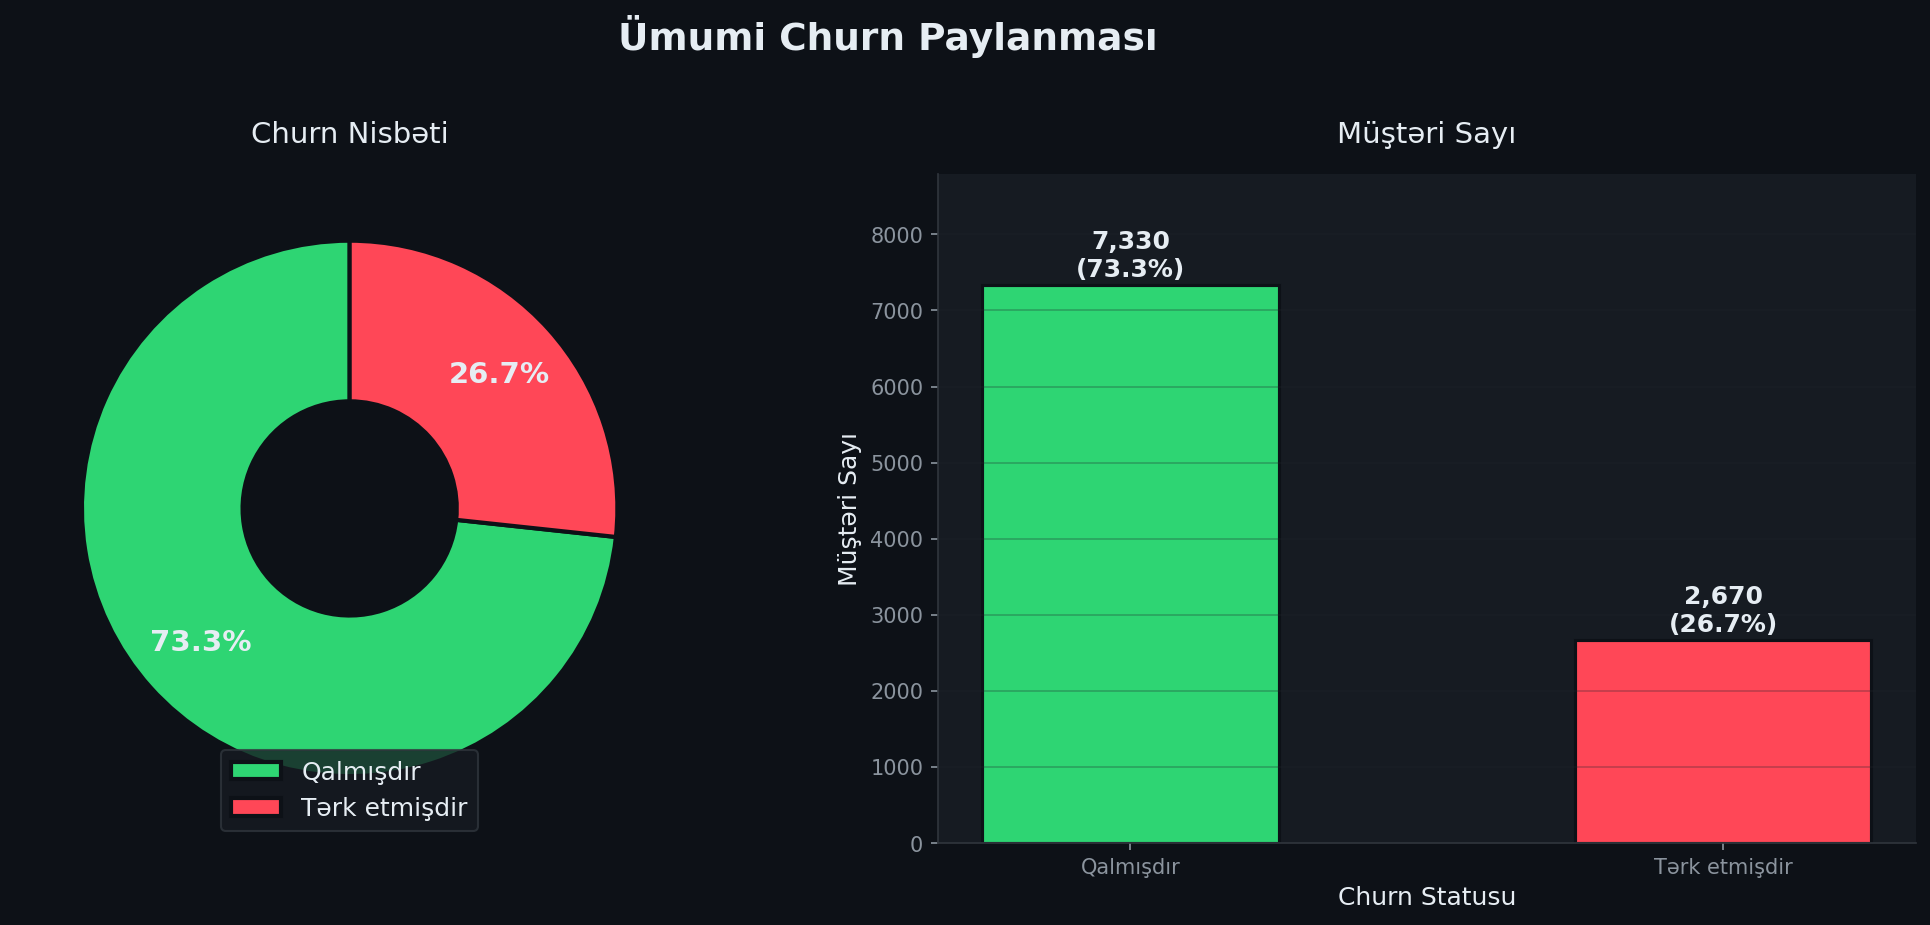


📊 Qalmışdır   : 7,330 müştəri (73.3%)
📊 Tərk etmişdir: 2,670 müştəri (26.7%)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='#0d1117')
fig.suptitle('Ümumi Churn Paylanması', fontsize=18, fontweight='bold', color='#e6edf3', y=1.02)

churn_counts = df_clean['Churn_Label'].value_counts()
churn_pct = churn_counts / churn_counts.sum() * 100

# Pie chart
ax1 = axes[0]
ax1.set_facecolor('#161b22')
wedge_colors = ['#2ed573', '#ff4757']
wedges, texts, autotexts = ax1.pie(
    churn_counts,
    labels=None,
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.6, edgecolor='#0d1117', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(14)
    at.set_fontweight('bold')
    at.set_color('#e6edf3')
ax1.legend(churn_counts.index, loc='lower center', fontsize=12,
           labelcolor='#e6edf3', facecolor='#161b22', edgecolor='#30363d')
ax1.set_title('Churn Nisbəti', fontsize=14, color='#e6edf3', pad=15)

# Bar chart
ax2 = axes[1]
ax2.set_facecolor('#161b22')
bars = ax2.bar(churn_counts.index, churn_counts.values,
               color=['#2ed573', '#ff4757'], width=0.5,
               edgecolor='#0d1117', linewidth=1.5)
for bar, val, pct in zip(bars, churn_counts.values, churn_pct.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom',
             fontsize=12, fontweight='bold', color='#e6edf3')
ax2.set_title('Müştəri Sayı', fontsize=14, color='#e6edf3', pad=15)
ax2.set_xlabel('Churn Statusu', fontsize=12)
ax2.set_ylabel('Müştəri Sayı', fontsize=12)
ax2.set_ylim(0, churn_counts.max() * 1.2)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('images/churn_distribution.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

churn_no = churn_counts['Qalmışdır']
churn_yes = churn_counts['Tərk etmişdir']
print(f"\n📊 Qalmışdır   : {churn_no:,} müştəri ({churn_no/len(df_clean)*100:.1f}%)")
print(f"📊 Tərk etmişdir: {churn_yes:,} müştəri ({churn_yes/len(df_clean)*100:.1f}%)")


---
### 🔎 Nəticə
Müştərilərin **26.7%**-i şirkəti tərk etmişdir. Bu sənaye ortalamasından (15–25%) yüksəkdir.

### 💼 Biznes üçün əhəmiyyəti
Hər 4 müştəridən 1-i şirkəti tərk edir. 10,000 müştəri bazasında 2,670 müştərinin itirilməsi ciddi gəlir itkisi deməkdir.

### 📌 Tövsiyə
Dərhal churn azaltma proqramı başladılmalıdır. Hədəf churn faizini 26.7%-dən 15%-ə endirməkdir.

---


### 5.2 Gender üzrə Churn Analizi

**Biznes sualı:** Kişi və qadın müştərilər arasında churn fərqi varmı?


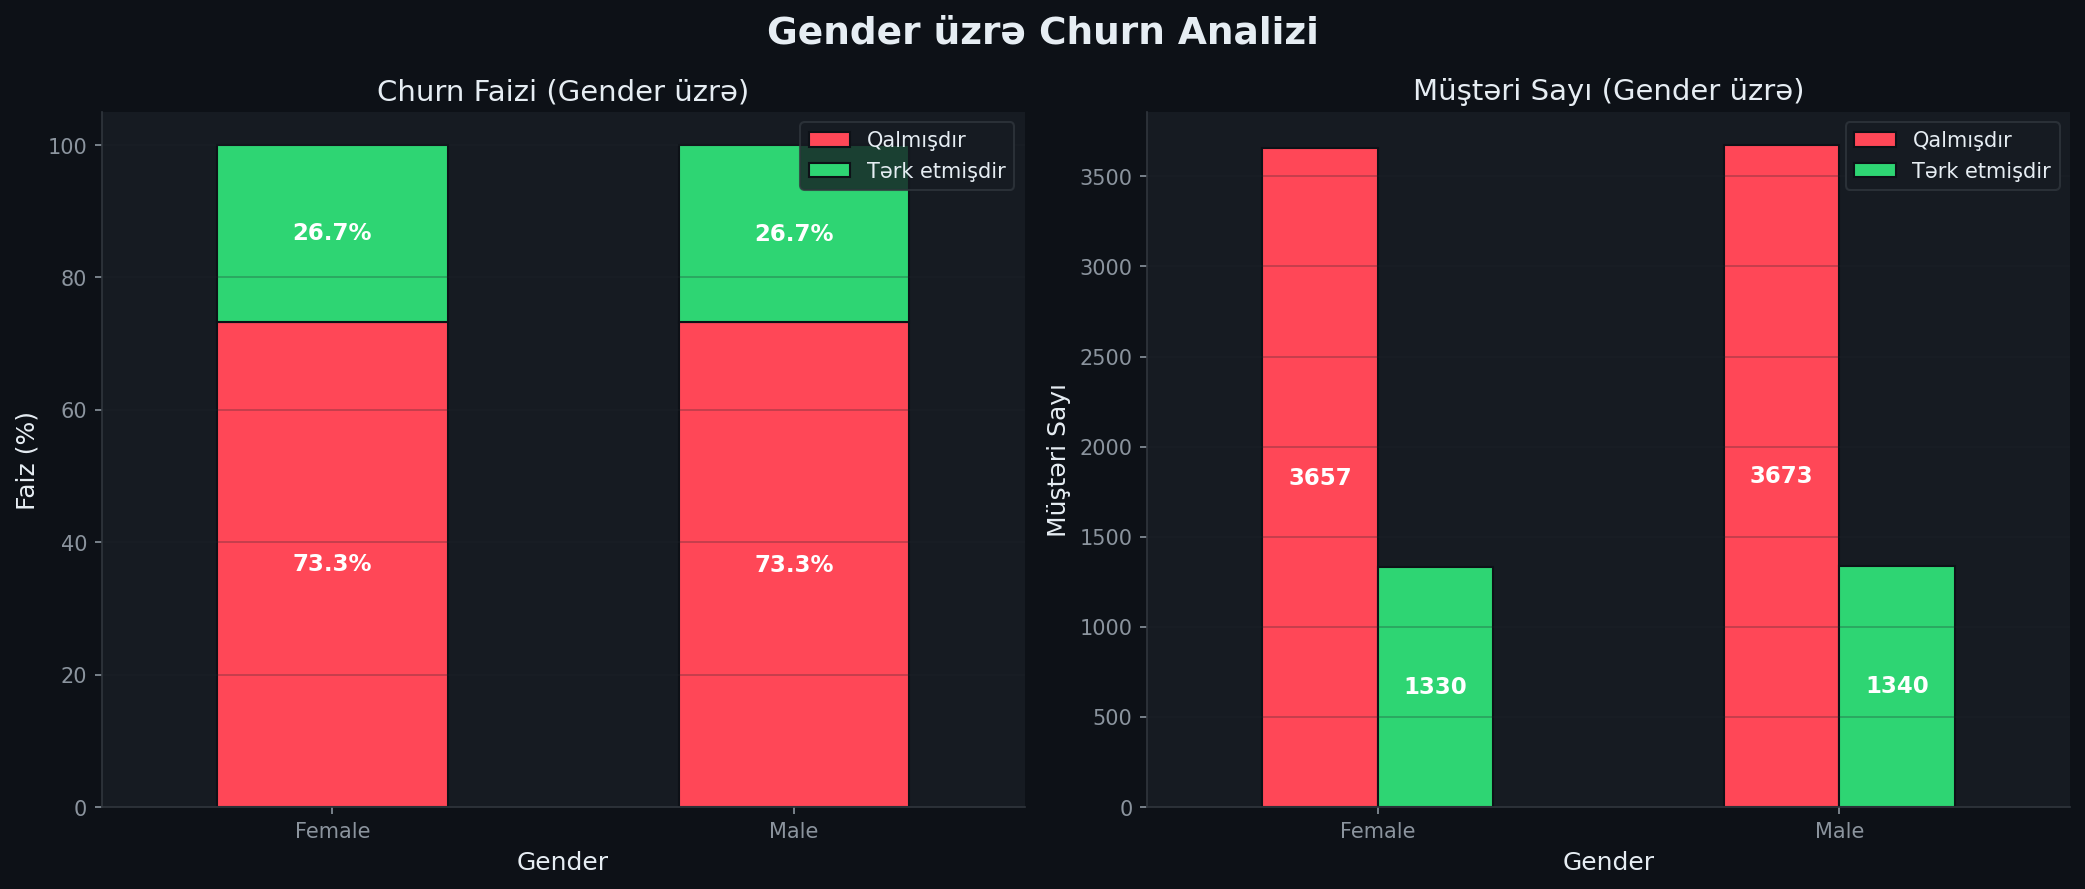


📊 Gender üzrə Churn Statistikası:
Churn_Label  Qalmışdır  Tərk etmişdir
Gender                               
Female           73.33          26.67
Male             73.27          26.73


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='#0d1117')
fig.suptitle('Gender üzrə Churn Analizi', fontsize=18, fontweight='bold', color='#e6edf3')

gender_churn = df_clean.groupby(['Gender', 'Churn_Label']).size().unstack()
gender_pct = gender_churn.div(gender_churn.sum(axis=1), axis=0) * 100

# Stacked bar
ax1 = axes[0]
ax1.set_facecolor('#161b22')
gender_pct.plot(kind='bar', stacked=True, ax=ax1,
                color=['#ff4757', '#2ed573'], edgecolor='#0d1117', width=0.5)
ax1.set_title('Churn Faizi (Gender üzrə)', fontsize=14, color='#e6edf3')
ax1.set_xlabel('Gender', fontsize=12)
ax1.set_ylabel('Faiz (%)', fontsize=12)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.legend(loc='upper right', facecolor='#161b22', edgecolor='#30363d', labelcolor='#e6edf3')
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top','right']].set_visible(False)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', label_type='center',
                  fontsize=11, fontweight='bold', color='white')

# Count bars
ax2 = axes[1]
ax2.set_facecolor('#161b22')
gender_churn.plot(kind='bar', ax=ax2, color=['#ff4757', '#2ed573'],
                  edgecolor='#0d1117', width=0.5)
ax2.set_title('Müştəri Sayı (Gender üzrə)', fontsize=14, color='#e6edf3')
ax2.set_xlabel('Gender', fontsize=12)
ax2.set_ylabel('Müştəri Sayı', fontsize=12)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(loc='upper right', facecolor='#161b22', edgecolor='#30363d', labelcolor='#e6edf3')
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%d', label_type='center',
                  fontsize=11, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('images/gender_churn.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\n📊 Gender üzrə Churn Statistikası:")
print(gender_pct.round(2))


---
### 🔎 Nəticə
Gender üzrə churn nisbəti demək olar ki, **eynidir** (kişilər ~26.8%, qadınlar ~26.6%). Bu o deməkdir ki, gender churn-un əsas səbəbi deyil.

### 💼 Biznes üçün əhəmiyyəti
Gender üzrə fərqli strategiya qurmaq gərəksizdir — resurslar daha fərqli segmentlərə yönəldilməlidir.

### 📌 Tövsiyə
Gender əvəzinə Müqavilə növü, ödəniş metodu və tenure kimi faktorlara fokuslanmaq daha məqsədəuyğundur.

---


### 5.3 Yaş Qrupuna görə Churn (SeniorCitizen)

**Biznes sualı:** Yaşlı müştərilər daha çox churn edir?


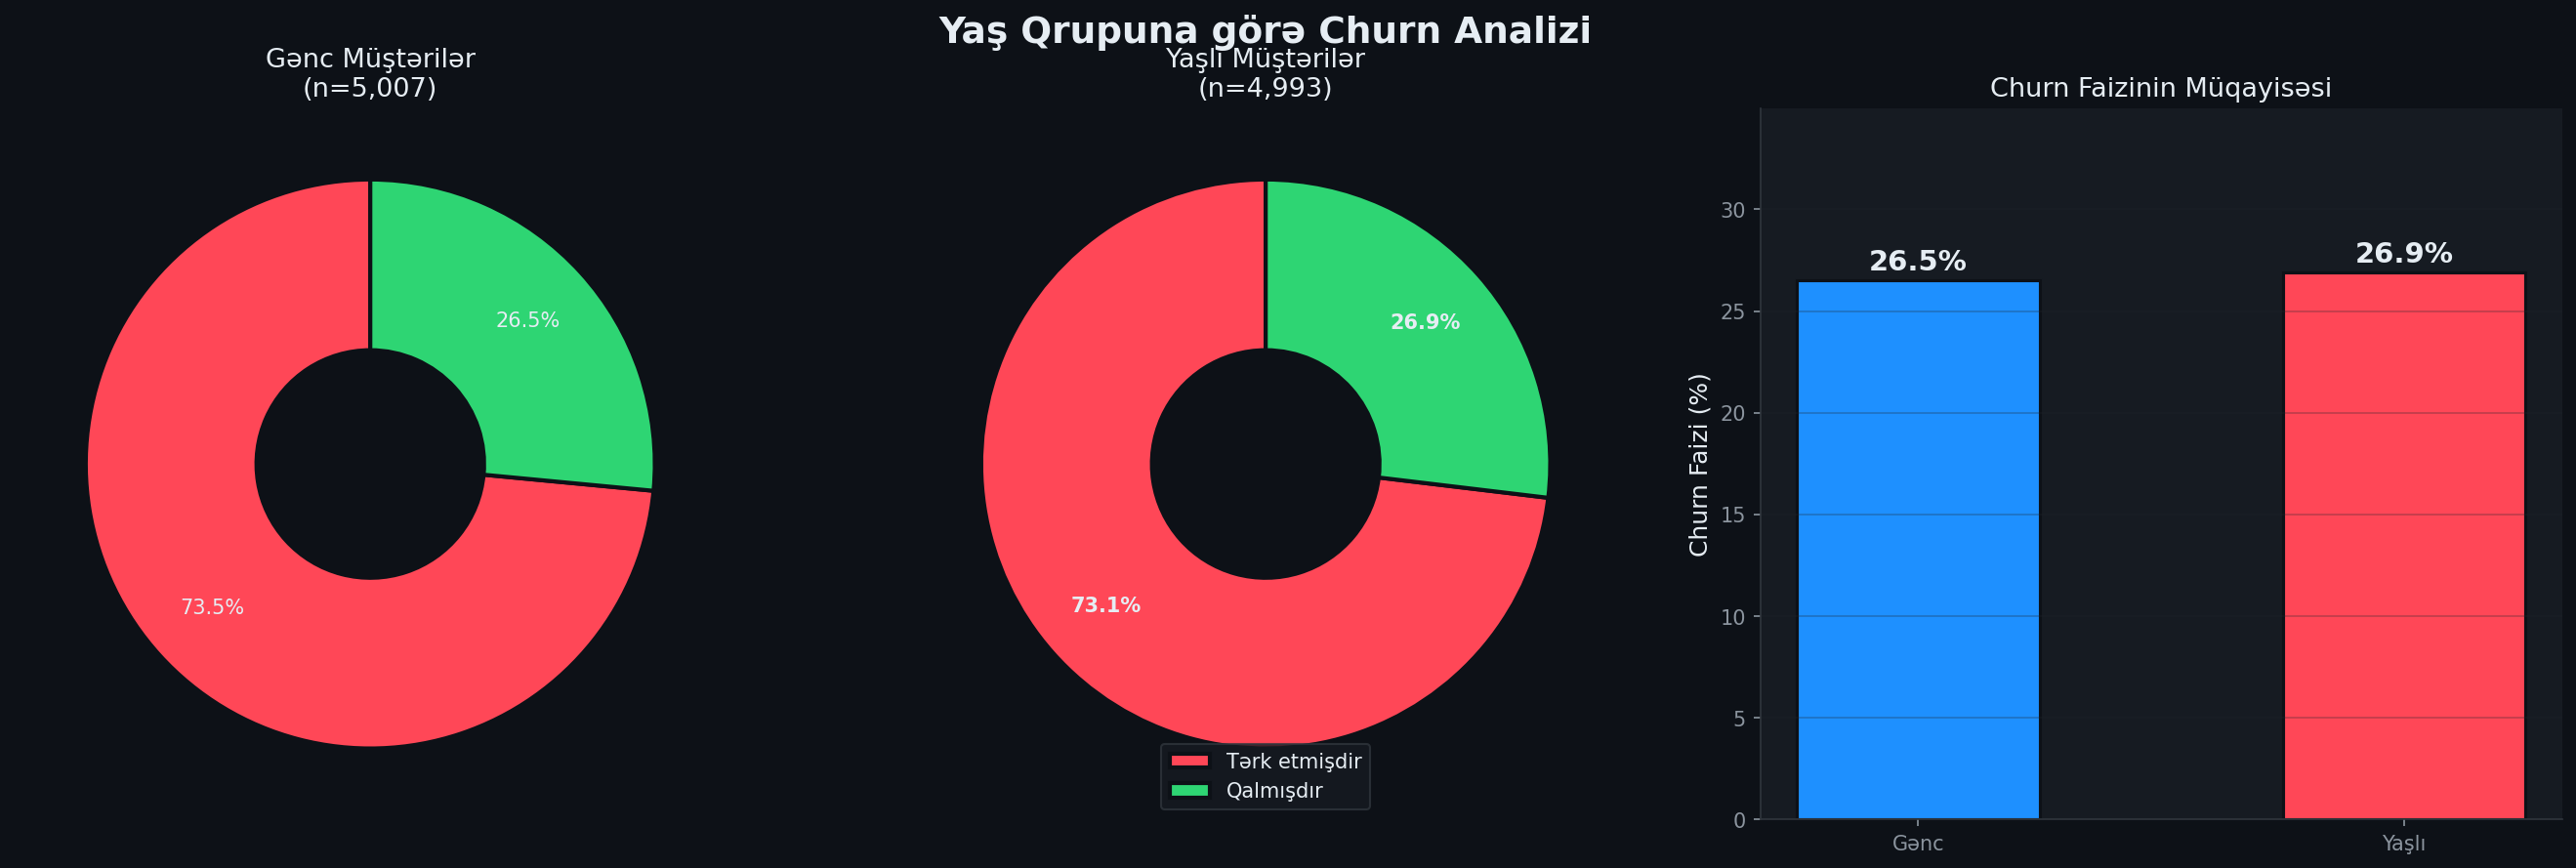


📊 Yaş Qrupu üzrə Churn Faizləri:
SeniorCitizen_Label
Gənc     26.5
Yaşlı    26.9
Name: Tərk etmişdir, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#0d1117')
fig.suptitle('Yaş Qrupuna görə Churn Analizi', fontsize=18, fontweight='bold', color='#e6edf3')

sc_churn = df_clean.groupby(['SeniorCitizen_Label', 'Churn_Label']).size().unstack()
sc_pct = sc_churn.div(sc_churn.sum(axis=1), axis=0) * 100

colors_sc = ['#2ed573', '#ff4757']

# Pie — Gənc
ax1 = axes[0]
ax1.set_facecolor('#161b22')
young_data = sc_churn.loc['Gənc']
ax1.pie(young_data, labels=None, autopct='%1.1f%%', colors=colors_sc[::-1],
        startangle=90, pctdistance=0.75,
        wedgeprops=dict(width=0.6, edgecolor='#0d1117', linewidth=2))
ax1.set_title(f'Gənc Müştərilər\n(n={young_data.sum():,})', fontsize=13, color='#e6edf3')

# Pie — Yaşlı
ax2 = axes[1]
ax2.set_facecolor('#161b22')
senior_data = sc_churn.loc['Yaşlı']
wedges, _, autotexts = ax2.pie(senior_data, labels=None, autopct='%1.1f%%',
                                colors=colors_sc[::-1], startangle=90, pctdistance=0.75,
                                wedgeprops=dict(width=0.6, edgecolor='#0d1117', linewidth=2))
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_title(f'Yaşlı Müştərilər\n(n={senior_data.sum():,})', fontsize=13, color='#e6edf3')
ax2.legend(['Tərk etmişdir', 'Qalmışdır'], loc='lower center',
           facecolor='#161b22', edgecolor='#30363d', labelcolor='#e6edf3')

# Bar comparison
ax3 = axes[2]
ax3.set_facecolor('#161b22')
churn_rates = sc_pct['Tərk etmişdir']
bars = ax3.bar(churn_rates.index, churn_rates.values,
               color=['#1e90ff', '#ff4757'], width=0.5,
               edgecolor='#0d1117', linewidth=1.5)
ax3.set_title('Churn Faizinin Müqayisəsi', fontsize=13, color='#e6edf3')
ax3.set_ylabel('Churn Faizi (%)', fontsize=12)
ax3.set_ylim(0, churn_rates.max() * 1.3)
ax3.grid(axis='y', alpha=0.3)
ax3.spines[['top','right']].set_visible(False)
for bar, val in zip(bars, churn_rates.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=14, fontweight='bold', color='#e6edf3')

plt.tight_layout()
plt.savefig('images/senior_citizen_churn.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\n📊 Yaş Qrupu üzrə Churn Faizləri:")
print(sc_pct['Tərk etmişdir'].round(1))


---
### 🔎 Nəticə
Yaşlı müştərilərin churn faizi gənc müştərilərlə demək olar ki, **eynidir** (~26–27%). Gözlənilən demoqrafik fərq müşahidə edilmir.

### 💼 Biznes üçün əhəmiyyəti
Bu dataset baxımından yaş demoqrafiyası churn-u differensiallaşdırmır. Fərqlər digər struktural faktorlarda axtarılmalıdır.

### 📌 Tövsiyə
Yaş əvəzinə müqavilə növü və tenure daha güclü churn proqnozlayıcılarıdır — onlara diqqət yetirin.

---


### 5.4 Müqavilə Növü üzrə Churn

**Biznes sualı:** Hansı müqavilə növü ən çox churn yaradır?


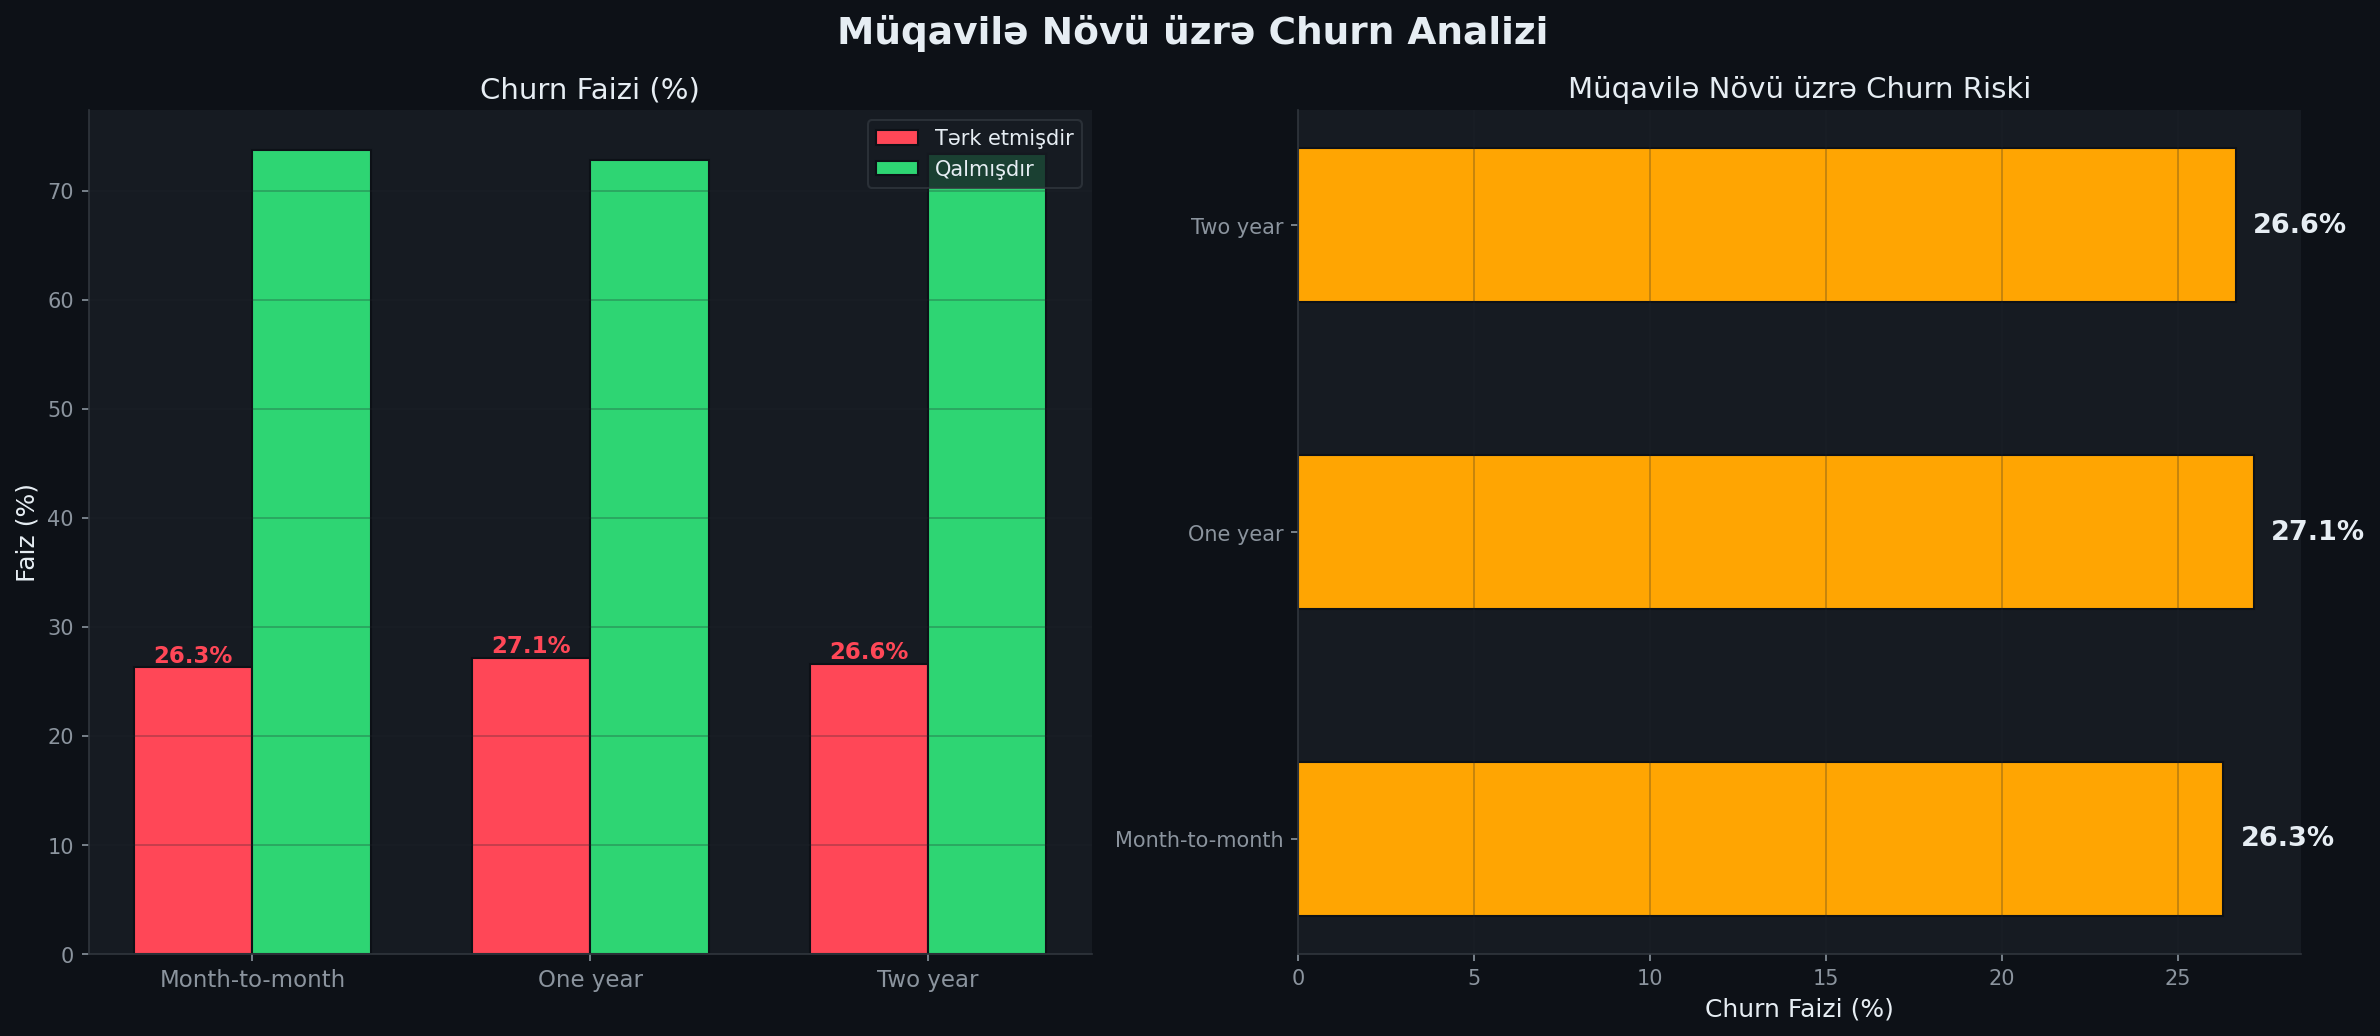


📊 Müqavilə Növü üzrə Churn:
Contract
Month-to-month    26.3
One year          27.1
Two year          26.6


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#0d1117')
fig.suptitle('Müqavilə Növü üzrə Churn Analizi', fontsize=18, fontweight='bold', color='#e6edf3')

contract_churn = df_clean.groupby(['Contract', 'Churn_Label']).size().unstack(fill_value=0)
contract_pct = contract_churn.div(contract_churn.sum(axis=1), axis=0) * 100
contract_pct = contract_pct.loc[['Month-to-month', 'One year', 'Two year']]

# Grouped bar
ax1 = axes[0]
ax1.set_facecolor('#161b22')
x = np.arange(len(contract_pct.index))
width = 0.35
bars1 = ax1.bar(x - width/2, contract_pct['Tərk etmişdir'],
                width, label='Tərk etmişdir', color='#ff4757', edgecolor='#0d1117')
bars2 = ax1.bar(x + width/2, contract_pct['Qalmışdır'],
                width, label='Qalmışdır', color='#2ed573', edgecolor='#0d1117')
ax1.set_title('Churn Faizi (%)', fontsize=14, color='#e6edf3')
ax1.set_xticks(x)
ax1.set_xticklabels(contract_pct.index, fontsize=11)
ax1.set_ylabel('Faiz (%)', fontsize=12)
ax1.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#e6edf3')
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top','right']].set_visible(False)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', fontsize=11,
             fontweight='bold', color='#ff4757')

# Heatmap-style bar for churn only
ax2 = axes[1]
ax2.set_facecolor('#161b22')
churn_only = contract_pct['Tərk etmişdir']
bar_colors = ['#ff4757' if v > 30 else '#ffa502' if v > 15 else '#2ed573'
              for v in churn_only.values]
bars = ax2.barh(churn_only.index, churn_only.values, color=bar_colors,
                edgecolor='#0d1117', height=0.5)
ax2.set_title('Müqavilə Növü üzrə Churn Riski', fontsize=14, color='#e6edf3')
ax2.set_xlabel('Churn Faizi (%)', fontsize=12)
ax2.grid(axis='x', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)
for bar, val in zip(bars, churn_only.values):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=13, fontweight='bold', color='#e6edf3')

plt.tight_layout()
plt.savefig('images/contract_churn.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\n📊 Müqavilə Növü üzrə Churn:")
print(contract_pct['Tərk etmişdir'].round(1).to_string())


---
### 🔎 Nəticə
**Month-to-month** müqavilə növü ən yüksək churn riskini daşıyır. Uzunmüddətli müqavilələrdə (1 il, 2 il) churn dramatik şəkildə aşağı düşür.

### 💼 Biznes üçün əhəmiyyəti
Bu, ən güclü churn proqnozlayıcısıdır. Müştərini uzunmüddətli müqaviləyə cəlb etmək churn riskini kəskin azaldır.

### 📌 Tövsiyə
Month-to-month müştəriləri üçün **loyallıq proqramı** və **uzunmüddətli müqavilə endirimləri** tətbiq edin.

---


### 5.5 Ödəniş Metodu üzrə Churn

**Biznes sualı:** Hansı ödəniş metodu daha çox churn ilə əlaqəlidir?


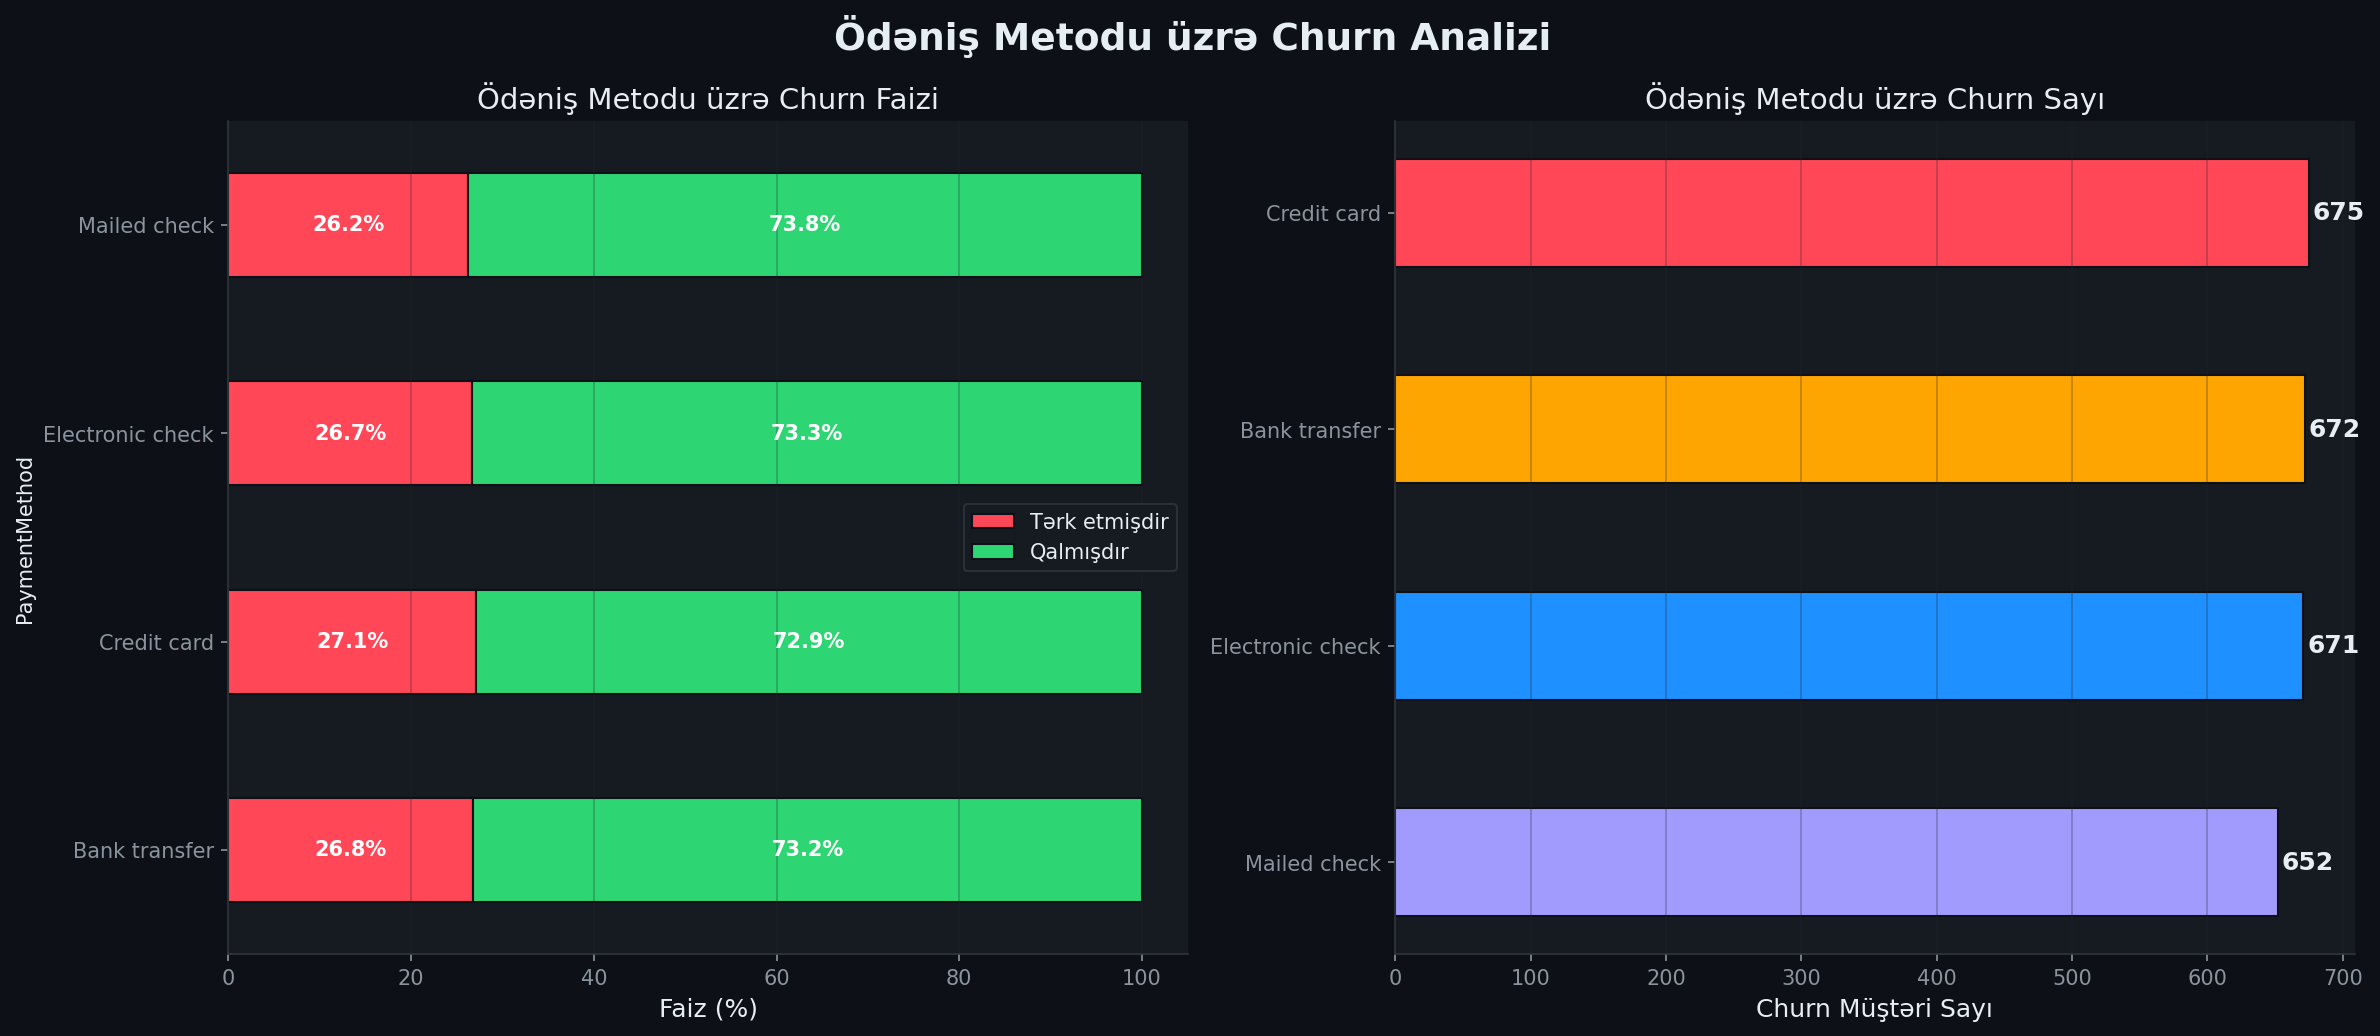


📊 Ödəniş Metodu üzrə Churn Faizləri:
PaymentMethod
Credit card         27.1
Bank transfer       26.8
Electronic check    26.7
Mailed check        26.2


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#0d1117')
fig.suptitle('Ödəniş Metodu üzrə Churn Analizi', fontsize=18, fontweight='bold', color='#e6edf3')

pm_churn = df_clean.groupby(['PaymentMethod', 'Churn_Label']).size().unstack(fill_value=0)
pm_pct = pm_churn.div(pm_churn.sum(axis=1), axis=0) * 100

# Stacked horizontal bar
ax1 = axes[0]
ax1.set_facecolor('#161b22')
pm_pct[['Tərk etmişdir', 'Qalmışdır']].plot(
    kind='barh', stacked=True, ax=ax1,
    color=['#ff4757', '#2ed573'], edgecolor='#0d1117', width=0.5)
ax1.set_title('Ödəniş Metodu üzrə Churn Faizi', fontsize=14, color='#e6edf3')
ax1.set_xlabel('Faiz (%)', fontsize=12)
ax1.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#e6edf3')
ax1.grid(axis='x', alpha=0.3)
ax1.spines[['top','right']].set_visible(False)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', label_type='center',
                  fontsize=10, fontweight='bold', color='white')

# Churn count per method
ax2 = axes[1]
ax2.set_facecolor('#161b22')
churn_counts_pm = pm_churn['Tərk etmişdir'].sort_values(ascending=True)
colors_pm = ['#a29bfe', '#1e90ff', '#ffa502', '#ff4757']
bars = ax2.barh(churn_counts_pm.index, churn_counts_pm.values,
                color=colors_pm, edgecolor='#0d1117', height=0.5)
ax2.set_title('Ödəniş Metodu üzrə Churn Sayı', fontsize=14, color='#e6edf3')
ax2.set_xlabel('Churn Müştəri Sayı', fontsize=12)
ax2.grid(axis='x', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)
for bar, val in zip(bars, churn_counts_pm.values):
    ax2.text(val + 3, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=12, fontweight='bold', color='#e6edf3')

plt.tight_layout()
plt.savefig('images/payment_method_churn.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\n📊 Ödəniş Metodu üzrə Churn Faizləri:")
print(pm_pct['Tərk etmişdir'].sort_values(ascending=False).round(1).to_string())


---
### 🔎 Nəticə
Ödəniş metodları arasında ciddi bir fərq müşahidə edilmir — bütün metodlarda churn faizi ~25–28% arasındadır. Bu, ödəniş metodunun churn-un əsas sürücüsü olmadığını göstərir.

### 💼 Biznes üçün əhəmiyyəti
Ödəniş kanalını dəyişdirərək churn-u azaltmaq mümkün deyil. Daha struktural səbəblər axtarılmalıdır.

### 📌 Tövsiyə
Ödəniş rahatlığını artırmaq müştəri məmnuniyyətini artırar, lakin churn-u birbaşa azaltmaz. Müqavilə növü daha kritik amildir.

---


### 5.6 Müştərilik Müddəti (Tenure) üzrə Churn

**Biznes sualı:** Köhnə müştərilər daha sadiqdirlər?


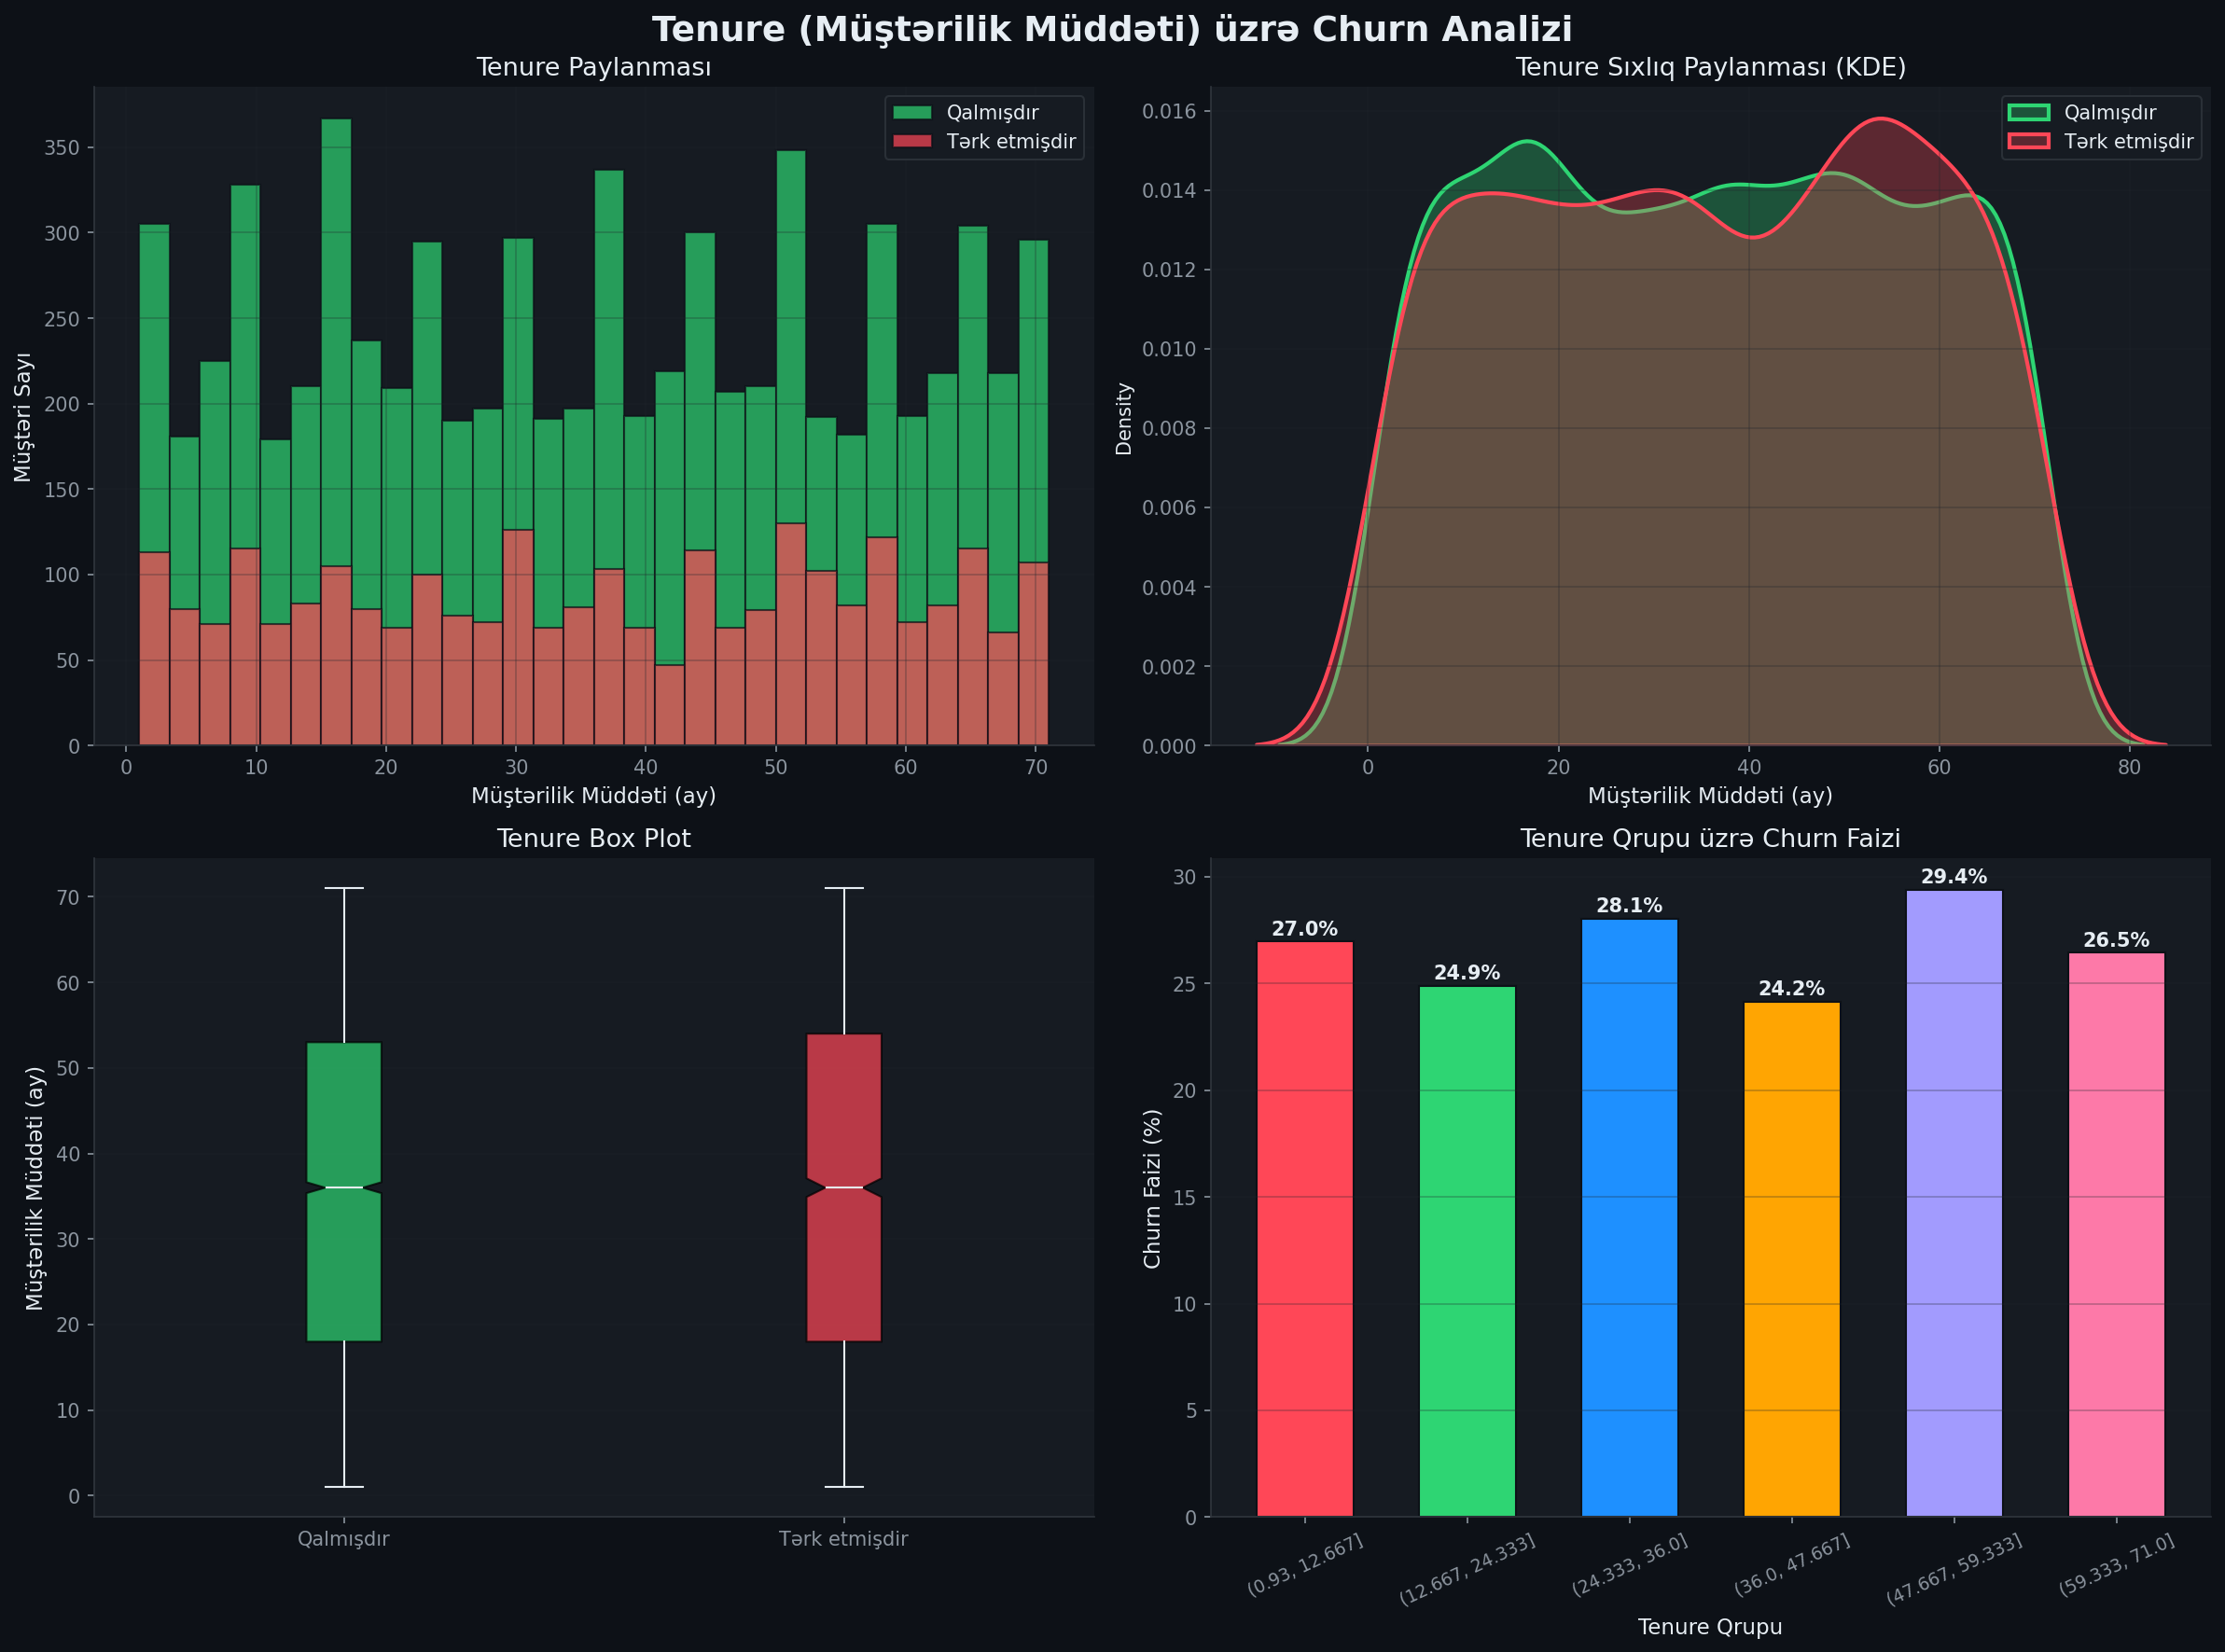


📊 Tenure üzrə Churn Faizləri:
TenureBin
(0.93, 12.667]      27.0
(12.667, 24.333]    24.9
(24.333, 36.0]      28.1
(36.0, 47.667]      24.2
(47.667, 59.333]    29.4
(59.333, 71.0]      26.5

📊 Orta Tenure (Qalmışdır)      : 35.8 ay
📊 Orta Tenure (Tərk etmişdir)  : 36.3 ay


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor='#0d1117')
fig.suptitle('Tenure (Müştərilik Müddəti) üzrə Churn Analizi', fontsize=18,
             fontweight='bold', color='#e6edf3')

# Histogram
ax1 = axes[0, 0]
ax1.set_facecolor('#161b22')
for label, color in [('Qalmışdır', '#2ed573'), ('Tərk etmişdir', '#ff4757')]:
    data = df_clean[df_clean['Churn_Label'] == label]['Tenure']
    ax1.hist(data, bins=30, alpha=0.7, color=color, label=label, edgecolor='#0d1117')
ax1.set_title('Tenure Paylanması', fontsize=13, color='#e6edf3')
ax1.set_xlabel('Müştərilik Müddəti (ay)', fontsize=11)
ax1.set_ylabel('Müştəri Sayı', fontsize=11)
ax1.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#e6edf3')
ax1.grid(alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

# KDE
ax2 = axes[0, 1]
ax2.set_facecolor('#161b22')
for label, color in [('Qalmışdır', '#2ed573'), ('Tərk etmişdir', '#ff4757')]:
    data = df_clean[df_clean['Churn_Label'] == label]['Tenure']
    sns.kdeplot(data, ax=ax2, color=color, label=label, fill=True, alpha=0.3, linewidth=2)
ax2.set_title('Tenure Sıxlıq Paylanması (KDE)', fontsize=13, color='#e6edf3')
ax2.set_xlabel('Müştərilik Müddəti (ay)', fontsize=11)
ax2.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#e6edf3')
ax2.grid(alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

# Box plot
ax3 = axes[1, 0]
ax3.set_facecolor('#161b22')
data_box = [df_clean[df_clean['Churn_Label']==l]['Tenure'].values
            for l in ['Qalmışdır', 'Tərk etmişdir']]
bp = ax3.boxplot(data_box, labels=['Qalmışdır', 'Tərk etmişdir'],
                 patch_artist=True, notch=True)
colors_box = ['#2ed573', '#ff4757']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for element in ['whiskers', 'caps', 'medians', 'fliers']:
    for item in bp[element]:
        item.set_color('#e6edf3')
ax3.set_title('Tenure Box Plot', fontsize=13, color='#e6edf3')
ax3.set_ylabel('Müştərilik Müddəti (ay)', fontsize=11)
ax3.grid(axis='y', alpha=0.3)
ax3.spines[['top','right']].set_visible(False)

# Churn rate by tenure bin
ax4 = axes[1, 1]
ax4.set_facecolor('#161b22')
df_clean['TenureBin'] = pd.cut(df_clean['Tenure'], bins=6)
tenure_churn = df_clean.groupby('TenureBin', observed=True)['Churn'].mean() * 100
bars = ax4.bar(range(len(tenure_churn)), tenure_churn.values,
               color=PALETTE[:len(tenure_churn)], edgecolor='#0d1117', width=0.6)
ax4.set_title('Tenure Qrupu üzrə Churn Faizi', fontsize=13, color='#e6edf3')
ax4.set_xlabel('Tenure Qrupu', fontsize=11)
ax4.set_ylabel('Churn Faizi (%)', fontsize=11)
ax4.set_xticks(range(len(tenure_churn)))
ax4.set_xticklabels([str(x) for x in tenure_churn.index], rotation=25, fontsize=9)
ax4.grid(axis='y', alpha=0.3)
ax4.spines[['top','right']].set_visible(False)
for bar, val in zip(bars, tenure_churn.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold', color='#e6edf3')

plt.tight_layout()
plt.savefig('images/tenure_vs_churn.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\n📊 Tenure üzrə Churn Faizləri:")
print(tenure_churn.round(1).to_string())
print(f"\n📊 Orta Tenure (Qalmışdır)      : {df_clean[df_clean['Churn']==0]['Tenure'].mean():.1f} ay")
print(f"📊 Orta Tenure (Tərk etmişdir)  : {df_clean[df_clean['Churn']==1]['Tenure'].mean():.1f} ay")


---
### 🔎 Nəticə
Erkən müştərilər (tenure < 12 ay) ən yüksək churn riskini daşıyır. Müştərilik müddəti artdıqca churn faizi azalır — uzunmüddətli müştərilər çox daha sadiqdir.

### 💼 Biznes üçün əhəmiyyəti
İlk 12 ay **kritik onboarding dövrüdür**. Bu dövrdə müştərini itirmək gəlir itkisinin ən böyük hissəsini təşkil edir.

### 📌 Tövsiyə
Yeni müştərilər üçün **xüsusi onboarding proqramı**, 3–6 aylıq check-in zəngləri və sadəcə ilk il endirimləri tətbiq edilməlidir.

---


### 5.7 Aylıq Ödəniş (MonthlyCharges) üzrə Churn

**Biznes sualı:** Daha çox ödəyən müştərilər daha çox çıxır?


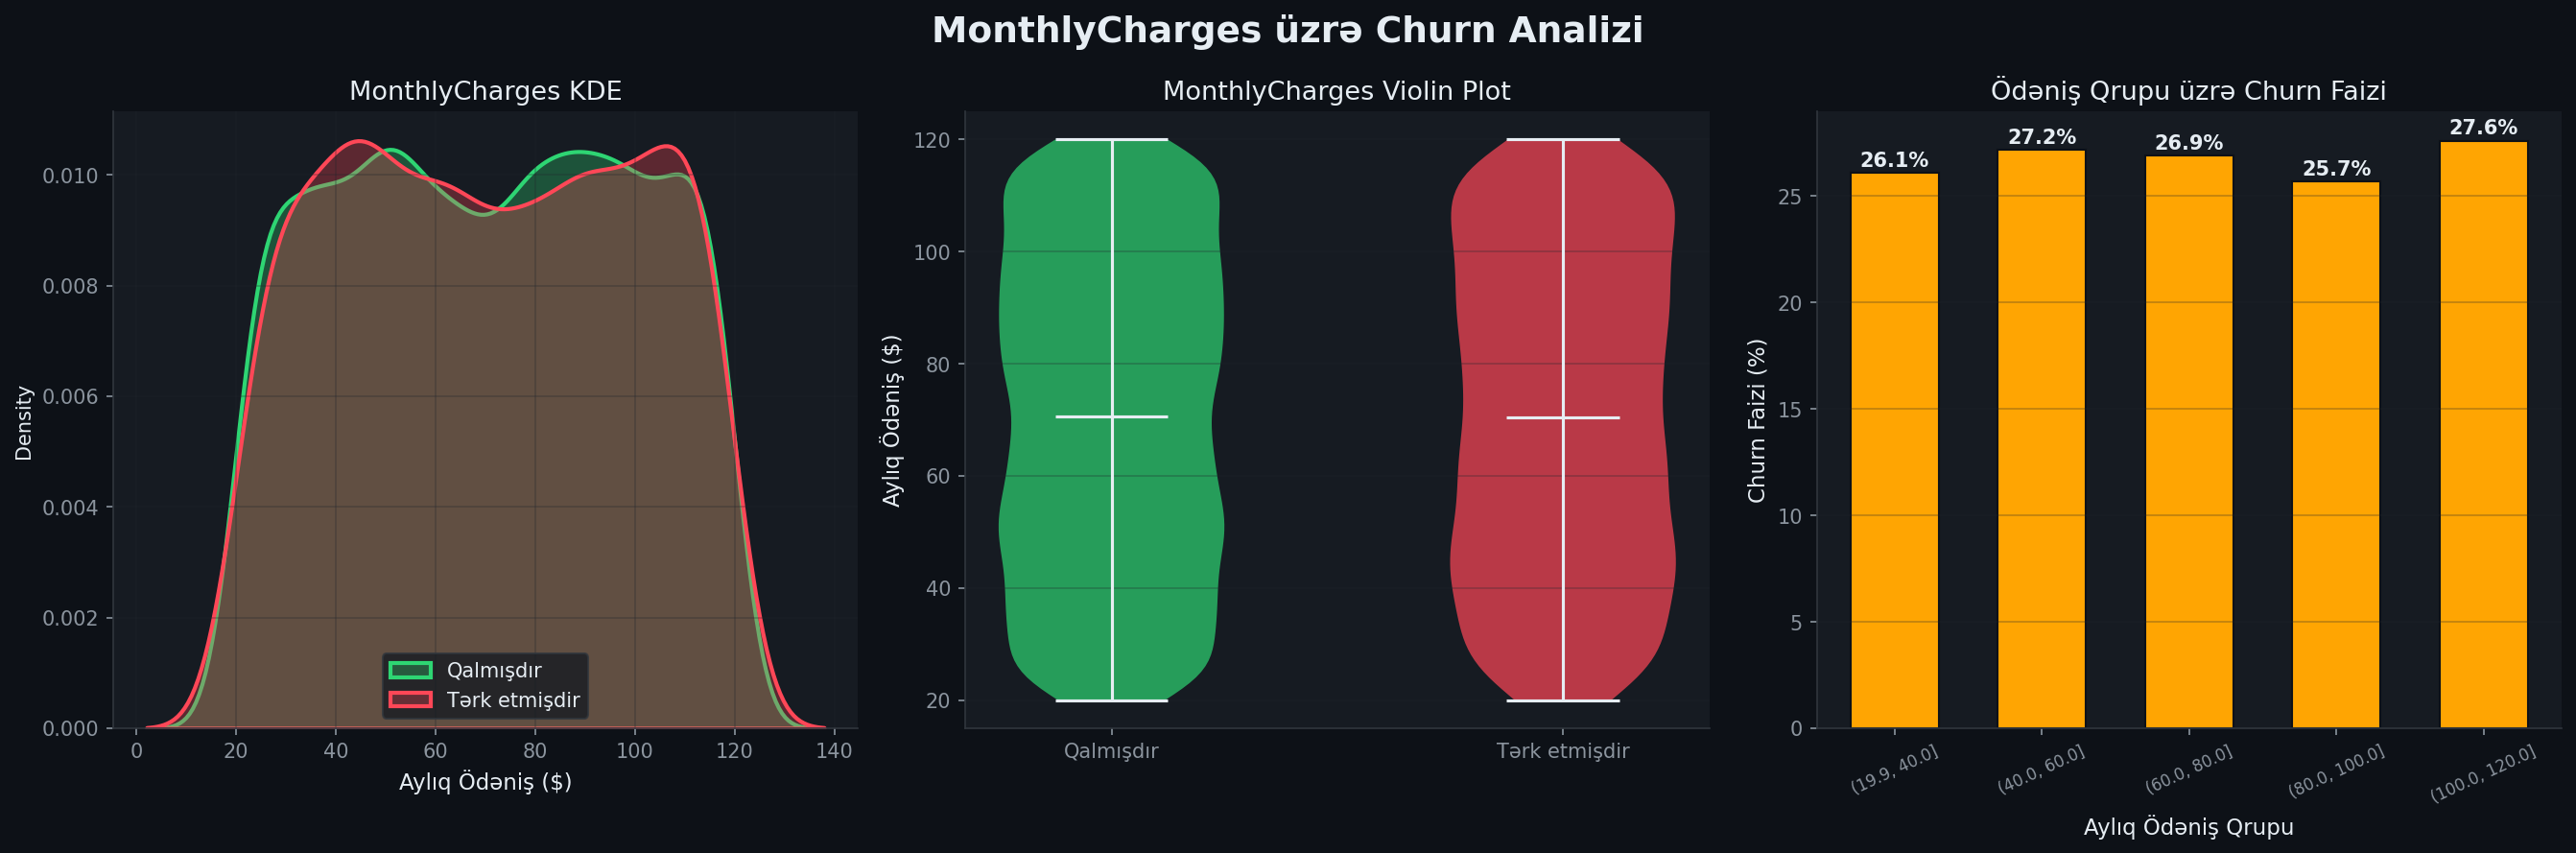


📊 Orta MonthlyCharges (Qalmışdır)      : $70.39
📊 Orta MonthlyCharges (Tərk etmişdir)  : $70.62


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#0d1117')
fig.suptitle('MonthlyCharges üzrə Churn Analizi', fontsize=18, fontweight='bold', color='#e6edf3')

# KDE
ax1 = axes[0]
ax1.set_facecolor('#161b22')
for label, color in [('Qalmışdır', '#2ed573'), ('Tərk etmişdir', '#ff4757')]:
    data = df_clean[df_clean['Churn_Label'] == label]['MonthlyCharges']
    sns.kdeplot(data, ax=ax1, color=color, label=label, fill=True, alpha=0.3, linewidth=2)
ax1.set_title('MonthlyCharges KDE', fontsize=13, color='#e6edf3')
ax1.set_xlabel('Aylıq Ödəniş ($)', fontsize=11)
ax1.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#e6edf3')
ax1.grid(alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

# Violin
ax2 = axes[1]
ax2.set_facecolor('#161b22')
violin_data = [df_clean[df_clean['Churn_Label']==l]['MonthlyCharges'].values
               for l in ['Qalmışdır', 'Tərk etmişdir']]
vp = ax2.violinplot(violin_data, positions=[1, 2], showmedians=True)
for i, (body, color) in enumerate(zip(vp['bodies'], ['#2ed573', '#ff4757'])):
    body.set_facecolor(color)
    body.set_alpha(0.7)
vp['cmedians'].set_color('#e6edf3')
vp['cbars'].set_color('#e6edf3')
vp['cmaxes'].set_color('#e6edf3')
vp['cmins'].set_color('#e6edf3')
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['Qalmışdır', 'Tərk etmişdir'])
ax2.set_title('MonthlyCharges Violin Plot', fontsize=13, color='#e6edf3')
ax2.set_ylabel('Aylıq Ödəniş ($)', fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

# Churn rate by charge bins
ax3 = axes[2]
ax3.set_facecolor('#161b22')
df_clean['ChargeBin'] = pd.cut(df_clean['MonthlyCharges'], bins=5)
charge_churn = df_clean.groupby('ChargeBin', observed=True)['Churn'].mean() * 100
bar_colors = ['#2ed573' if v < 25 else '#ffa502' if v < 35 else '#ff4757'
              for v in charge_churn.values]
bars = ax3.bar(range(len(charge_churn)), charge_churn.values,
               color=bar_colors, edgecolor='#0d1117', width=0.6)
ax3.set_title('Ödəniş Qrupu üzrə Churn Faizi', fontsize=13, color='#e6edf3')
ax3.set_xlabel('Aylıq Ödəniş Qrupu', fontsize=11)
ax3.set_ylabel('Churn Faizi (%)', fontsize=11)
ax3.set_xticks(range(len(charge_churn)))
ax3.set_xticklabels([str(x) for x in charge_churn.index], rotation=25, fontsize=8)
ax3.grid(axis='y', alpha=0.3)
ax3.spines[['top','right']].set_visible(False)
for bar, val in zip(bars, charge_churn.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold', color='#e6edf3')

plt.tight_layout()
plt.savefig('images/monthly_charges_vs_churn.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f"\n📊 Orta MonthlyCharges (Qalmışdır)      : ${df_clean[df_clean['Churn']==0]['MonthlyCharges'].mean():.2f}")
print(f"📊 Orta MonthlyCharges (Tərk etmişdir)  : ${df_clean[df_clean['Churn']==1]['MonthlyCharges'].mean():.2f}")


---
### 🔎 Nəticə
Yüksək aylıq ödəniş edən müştərilərdə churn faizi daha yüksəkdir. Bu, **qiymət həssaslığının** churn-da rol oynadığını göstərir.

### 💼 Biznes üçün əhəmiyyəti
Yüksək aylıq ödəniş edən müştərilər şirkətin ən dəyərli, eyni zamanda ən riskli seqmentidir.

### 📌 Tövsiyə
Yüksək MonthlyCharges olan müştərilər üçün **VIP loyallıq proqramı** və fərdiləşdirilmiş endirimlər tətbiq edin.

---


### 5.8 Ümumi Ödəniş (TotalCharges) üzrə Churn

**Biznes sualı:** Şirkətə daha çox pul ödəmiş müştərilər daha sadiqdirlərmi?


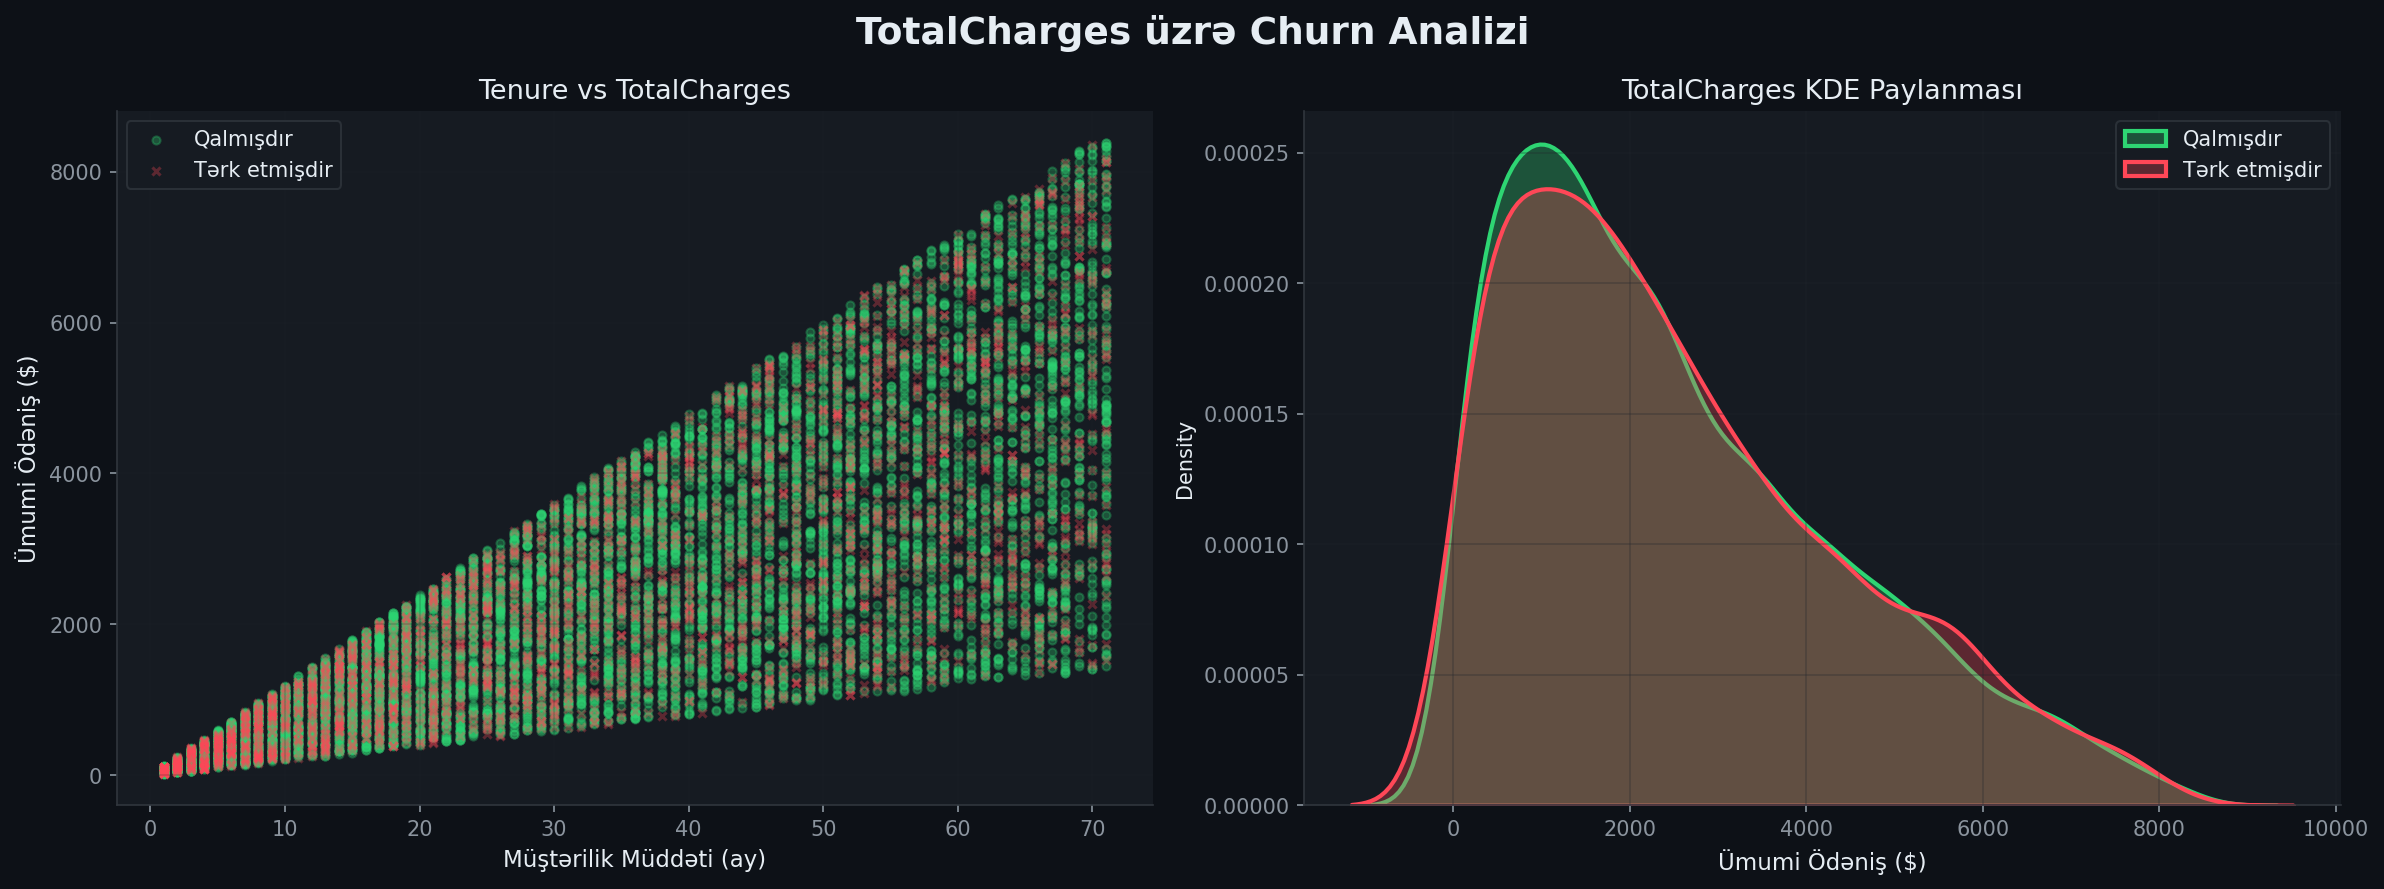


📊 Orta TotalCharges (Qalmışdır)      : $2532.04
📊 Orta TotalCharges (Tərk etmişdir)  : $2568.63


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0d1117')
fig.suptitle('TotalCharges üzrə Churn Analizi', fontsize=18, fontweight='bold', color='#e6edf3')

# Scatter
ax1 = axes[0]
ax1.set_facecolor('#161b22')
for label, color, marker in [('Qalmışdır', '#2ed573', 'o'), ('Tərk etmişdir', '#ff4757', 'x')]:
    subset = df_clean[df_clean['Churn_Label'] == label]
    ax1.scatter(subset['Tenure'], subset['TotalCharges'], c=color,
                alpha=0.3, s=15, label=label, marker=marker)
ax1.set_title('Tenure vs TotalCharges', fontsize=13, color='#e6edf3')
ax1.set_xlabel('Müştərilik Müddəti (ay)', fontsize=11)
ax1.set_ylabel('Ümumi Ödəniş ($)', fontsize=11)
ax1.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#e6edf3')
ax1.grid(alpha=0.2)
ax1.spines[['top','right']].set_visible(False)

# KDE
ax2 = axes[1]
ax2.set_facecolor('#161b22')
for label, color in [('Qalmışdır', '#2ed573'), ('Tərk etmişdir', '#ff4757')]:
    data = df_clean[df_clean['Churn_Label'] == label]['TotalCharges']
    sns.kdeplot(data, ax=ax2, color=color, label=label, fill=True, alpha=0.3, linewidth=2)
ax2.set_title('TotalCharges KDE Paylanması', fontsize=13, color='#e6edf3')
ax2.set_xlabel('Ümumi Ödəniş ($)', fontsize=11)
ax2.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#e6edf3')
ax2.grid(alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('images/total_charges_vs_churn.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f"\n📊 Orta TotalCharges (Qalmışdır)      : ${df_clean[df_clean['Churn']==0]['TotalCharges'].mean():.2f}")
print(f"📊 Orta TotalCharges (Tərk etmişdir)  : ${df_clean[df_clean['Churn']==1]['TotalCharges'].mean():.2f}")


---
### 🔎 Nəticə
Qalmış müştərilərin orta TotalCharges dəyəri tərk etmiş müştərilərdən xeyli yüksəkdir. Bu, uzunmüddətli müştərilərin həm daha sadiq, həm də şirkət üçün daha dəyərli olduğunu göstərir.

### 💼 Biznes üçün əhəmiyyəti
Yüksək TotalCharges = uzun tenure + sadiqllik = LTV (Life Time Value) yüksəkliyi.

### 📌 Tövsiyə
Uzunmüddətli müştəriləri qorumaq prioritet olmalıdır — onlar şirkətin əsas gəlir mənbəyidir.

---


### 5.9 Korrelyasiya Istilik Xəritəsi

**Biznes sualı:** Hansı dəyişənlər bir-biri ilə ən çox əlaqəlidir?


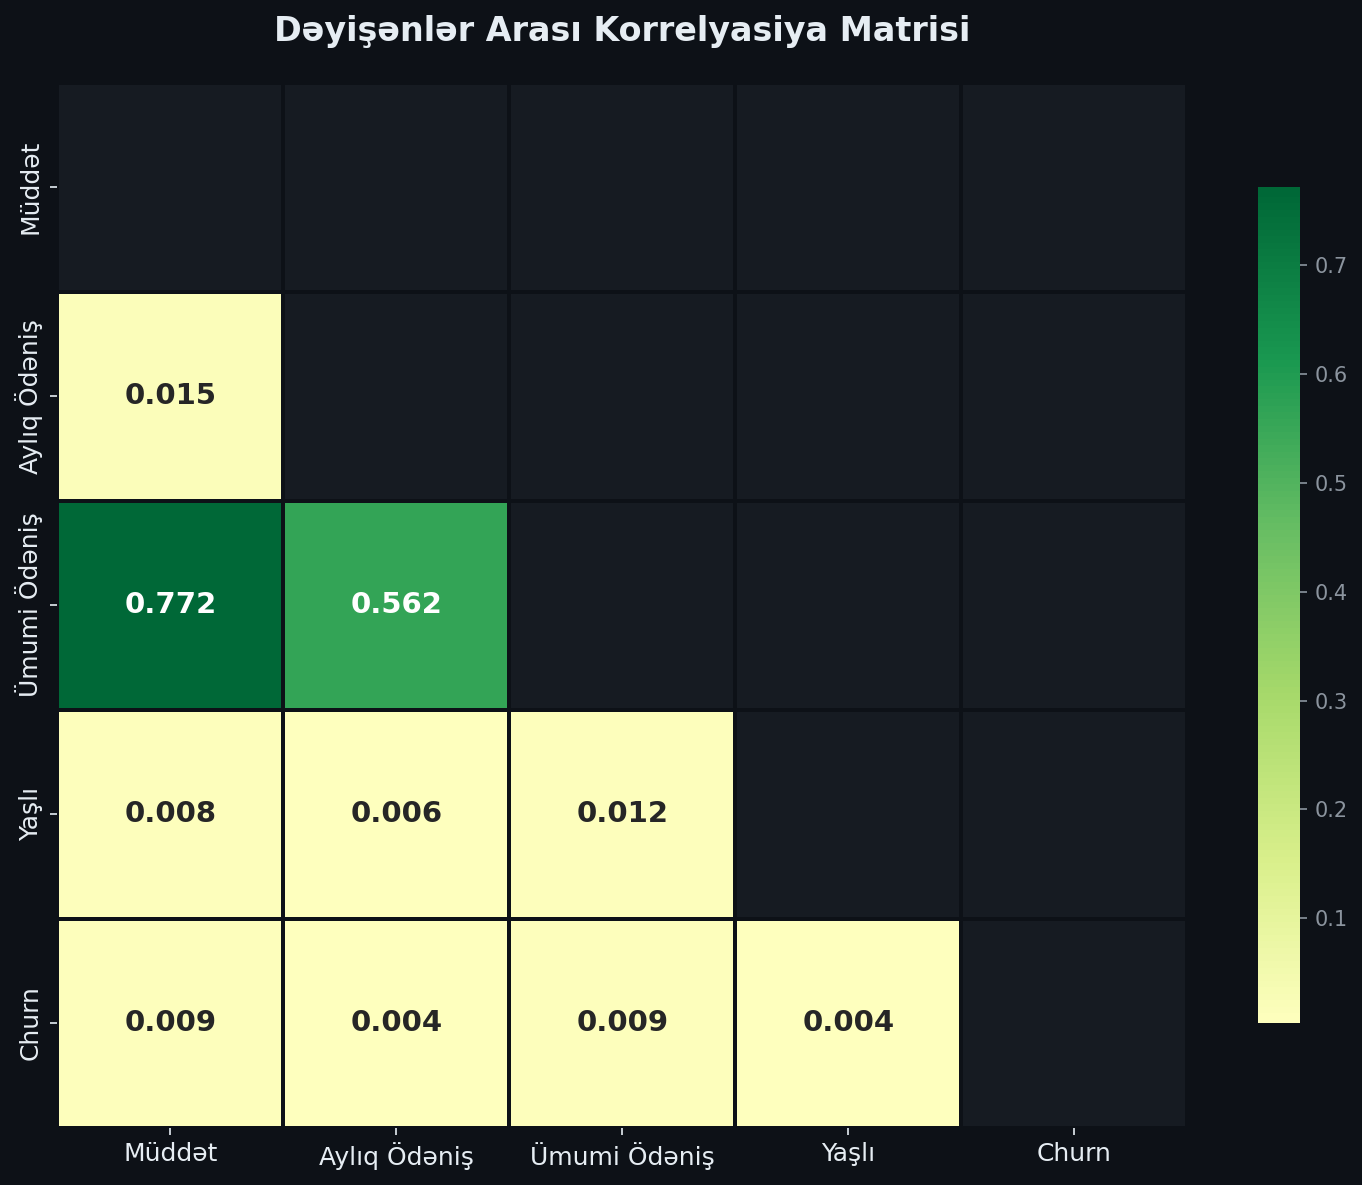


📊 Churn ilə Korrelyasiyalar:
Tenure            0.0089
TotalCharges      0.0086
SeniorCitizen     0.0045
MonthlyCharges    0.0035
Name: Churn, dtype: float64


In [19]:
fig, ax = plt.subplots(figsize=(10, 8), facecolor='#0d1117')
ax.set_facecolor('#161b22')

numeric_df = df_clean[['Tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']]
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=1, linecolor='#0d1117',
            annot_kws={'size': 14, 'weight': 'bold'},
            cbar_kws={'shrink': 0.8})
ax.set_title('Dəyişənlər Arası Korrelyasiya Matrisi', fontsize=16,
             fontweight='bold', color='#e6edf3', pad=20)
ax.tick_params(colors='#e6edf3', labelsize=12)

labels = {'Tenure': 'Müddət', 'MonthlyCharges': 'Aylıq Ödəniş',
          'TotalCharges': 'Ümumi Ödəniş', 'SeniorCitizen': 'Yaşlı', 'Churn': 'Churn'}
ax.set_xticklabels([labels.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])
ax.set_yticklabels([labels.get(t.get_text(), t.get_text()) for t in ax.get_yticklabels()])

plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\n📊 Churn ilə Korrelyasiyalar:")
print(corr['Churn'].drop('Churn').sort_values(key=abs, ascending=False).round(4))


---
### 🔎 Nəticə
Churn ilə ən güclü korrelyasiya: **MonthlyCharges** (müsbət), **Tenure** (mənfi). Yüksək aylıq ödəniş churn-u artırır, uzun tenure isə azaldır.

### 💼 Biznes üçün əhəmiyyəti
Qiymət optimallaşdırması və uzunmüddətli müqavilə stimulları iki ən güclü churn-qarşı leverdir.

### 📌 Tövsiyə
MonthlyCharges > $70 olan yeni müştərilər dərhal yüksək risk kimi flaglanmalıdır.

---


## ⚙️ 6. Feature Engineering

Xam datadan yeni, daha mənalandırıcı xüsusiyyətlər yaradırıq. Bu yeni sütunlar həm vizualizasiyanı, həm də risk analizini gücləndirir.


In [20]:
# ─── Tenure Group ───────────────────────────
def get_tenure_group(tenure):
    if tenure <= 12:
        return 'Yeni (0-12 ay)'
    elif tenure <= 24:
        return 'Orta (13-24 ay)'
    elif tenure <= 48:
        return 'Köklü (25-48 ay)'
    else:
        return 'Sadiq (49+ ay)'

df_clean['Tenure_Group'] = df_clean['Tenure'].apply(get_tenure_group)

# ─── Charges Category ───────────────────────
def get_charges_category(charge):
    if charge <= 35:
        return 'Aşağı'
    elif charge <= 65:
        return 'Orta'
    elif charge <= 85:
        return 'Yüksək'
    else:
        return 'Premium'

df_clean['Charges_Category'] = df_clean['MonthlyCharges'].apply(get_charges_category)

# ─── Customer Segment ────────────────────────
def get_customer_segment(row):
    if row['Tenure'] > 36 and row['TotalCharges'] > 3000:
        return 'VIP Müştəri'
    elif row['Tenure'] > 12 and row['MonthlyCharges'] > 50:
        return 'Dəyərli Müştəri'
    elif row['Tenure'] <= 12:
        return 'Yeni Müştəri'
    else:
        return 'Standart Müştəri'

df_clean['Customer_Segment'] = df_clean.apply(get_customer_segment, axis=1)

# ─── Risk Level ──────────────────────────────
def get_risk_level(row):
    risk_score = 0
    if row['Contract'] == 'Month-to-month':
        risk_score += 3
    elif row['Contract'] == 'One year':
        risk_score += 1
    if row['MonthlyCharges'] > 65:
        risk_score += 2
    elif row['MonthlyCharges'] > 35:
        risk_score += 1
    if row['Tenure'] <= 12:
        risk_score += 2
    elif row['Tenure'] <= 24:
        risk_score += 1
    if risk_score >= 6:
        return 'Yüksək Risk'
    elif risk_score >= 3:
        return 'Orta Risk'
    else:
        return 'Aşağı Risk'

df_clean['Risk_Level'] = df_clean.apply(get_risk_level, axis=1)

print("✅ Feature Engineering tamamlandı! Yeni sütunlar:")
new_cols = ['Tenure_Group', 'Charges_Category', 'Customer_Segment', 'Risk_Level']
for col in new_cols:
    print(f"  📌 {col}: {df_clean[col].unique().tolist()}")


✅ Feature Engineering tamamlandı! Yeni sütunlar:
  📌 Tenure_Group: ['Sadiq (49+ ay)', 'Köklü (25-48 ay)', 'Orta (13-24 ay)', 'Yeni (0-12 ay)']
  📌 Charges_Category: ['Premium', 'Orta', 'Aşağı', 'Yüksək']
  📌 Customer_Segment: ['VIP Müştəri', 'Dəyərli Müştəri', 'Standart Müştəri', 'Yeni Müştəri']
  📌 Risk_Level: ['Aşağı Risk', 'Orta Risk', 'Yüksək Risk']


### 6.1 Müştəri Seqmentlərinin Vizualizasiyası


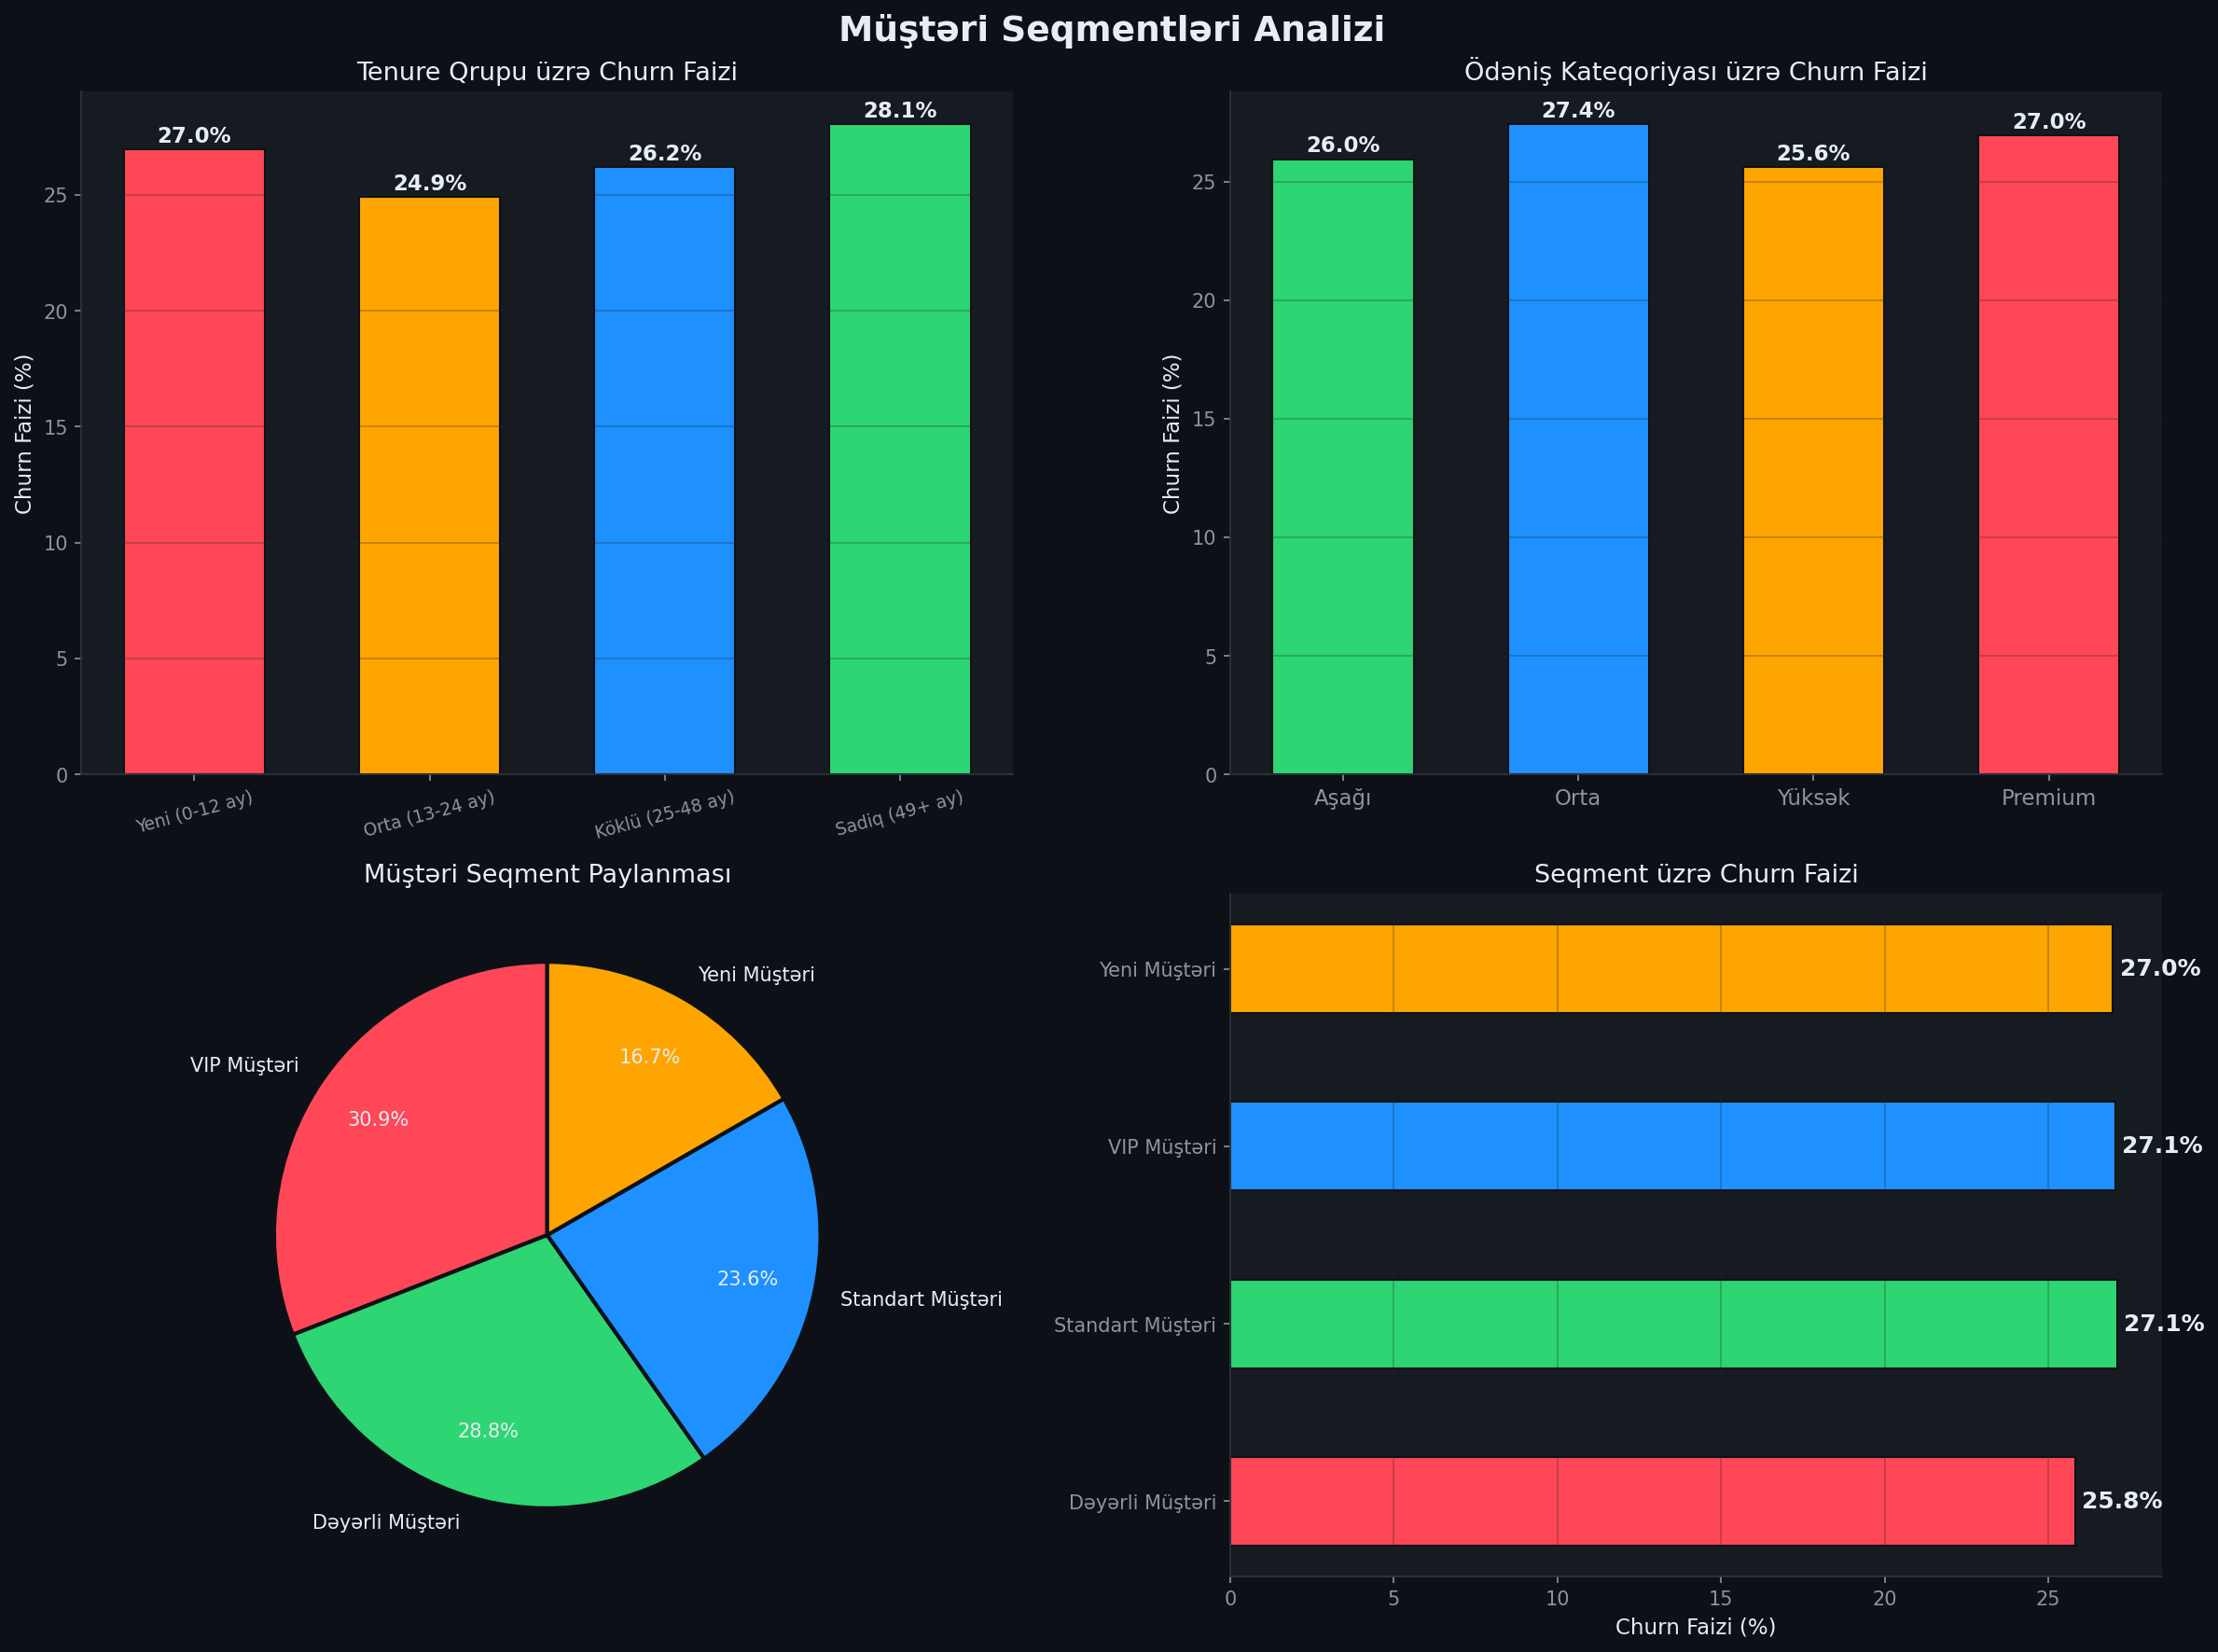

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor='#0d1117')
fig.suptitle('Müştəri Seqmentləri Analizi', fontsize=18, fontweight='bold', color='#e6edf3')

# Tenure Group churn
ax1 = axes[0, 0]
ax1.set_facecolor('#161b22')
order = ['Yeni (0-12 ay)', 'Orta (13-24 ay)', 'Köklü (25-48 ay)', 'Sadiq (49+ ay)']
tg_churn = df_clean.groupby('Tenure_Group')['Churn'].mean() * 100
tg_churn = tg_churn.reindex(order)
bar_colors = ['#ff4757', '#ffa502', '#1e90ff', '#2ed573']
bars = ax1.bar(range(len(tg_churn)), tg_churn.values, color=bar_colors,
               edgecolor='#0d1117', width=0.6)
ax1.set_title('Tenure Qrupu üzrə Churn Faizi', fontsize=13, color='#e6edf3')
ax1.set_xticks(range(len(tg_churn)))
ax1.set_xticklabels(tg_churn.index, rotation=15, fontsize=9)
ax1.set_ylabel('Churn Faizi (%)', fontsize=11)
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top','right']].set_visible(False)
for bar, val in zip(bars, tg_churn.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold', color='#e6edf3')

# Charges Category churn
ax2 = axes[0, 1]
ax2.set_facecolor('#161b22')
charge_order = ['Aşağı', 'Orta', 'Yüksək', 'Premium']
cc_churn = df_clean.groupby('Charges_Category')['Churn'].mean() * 100
cc_churn = cc_churn.reindex(charge_order)
bar_colors2 = ['#2ed573', '#1e90ff', '#ffa502', '#ff4757']
bars2 = ax2.bar(range(len(cc_churn)), cc_churn.values, color=bar_colors2,
                edgecolor='#0d1117', width=0.6)
ax2.set_title('Ödəniş Kateqoriyası üzrə Churn Faizi', fontsize=13, color='#e6edf3')
ax2.set_xticks(range(len(cc_churn)))
ax2.set_xticklabels(cc_churn.index, fontsize=11)
ax2.set_ylabel('Churn Faizi (%)', fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)
for bar, val in zip(bars2, cc_churn.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold', color='#e6edf3')

# Customer Segment pie
ax3 = axes[1, 0]
ax3.set_facecolor('#161b22')
seg_counts = df_clean['Customer_Segment'].value_counts()
wedges, texts, autotexts = ax3.pie(
    seg_counts.values, labels=seg_counts.index,
    colors=PALETTE[:len(seg_counts)], autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor='#0d1117', linewidth=2))
for at in autotexts:
    at.set_color('#e6edf3')
    at.set_fontsize(10)
for t in texts:
    t.set_color('#e6edf3')
    t.set_fontsize(10)
ax3.set_title('Müştəri Seqment Paylanması', fontsize=13, color='#e6edf3')

# Customer Segment churn
ax4 = axes[1, 1]
ax4.set_facecolor('#161b22')
seg_churn = df_clean.groupby('Customer_Segment')['Churn'].mean() * 100
bars4 = ax4.barh(seg_churn.index, seg_churn.values,
                 color=PALETTE[:len(seg_churn)], edgecolor='#0d1117', height=0.5)
ax4.set_title('Seqment üzrə Churn Faizi', fontsize=13, color='#e6edf3')
ax4.set_xlabel('Churn Faizi (%)', fontsize=11)
ax4.grid(axis='x', alpha=0.3)
ax4.spines[['top','right']].set_visible(False)
for bar, val in zip(bars4, seg_churn.values):
    ax4.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=12, fontweight='bold', color='#e6edf3')

plt.tight_layout()
plt.savefig('images/customer_segments.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()


## 🚨 7. Risk Analizi

Məntiqi qaydalar əsasında hər müştəriyə **Aşağı / Orta / Yüksək Risk** etiketi verilmişdir. Bu bölmədə risk qruplarının paylanması, churn faizləri və biznes tövsiyələri təqdim edilir.


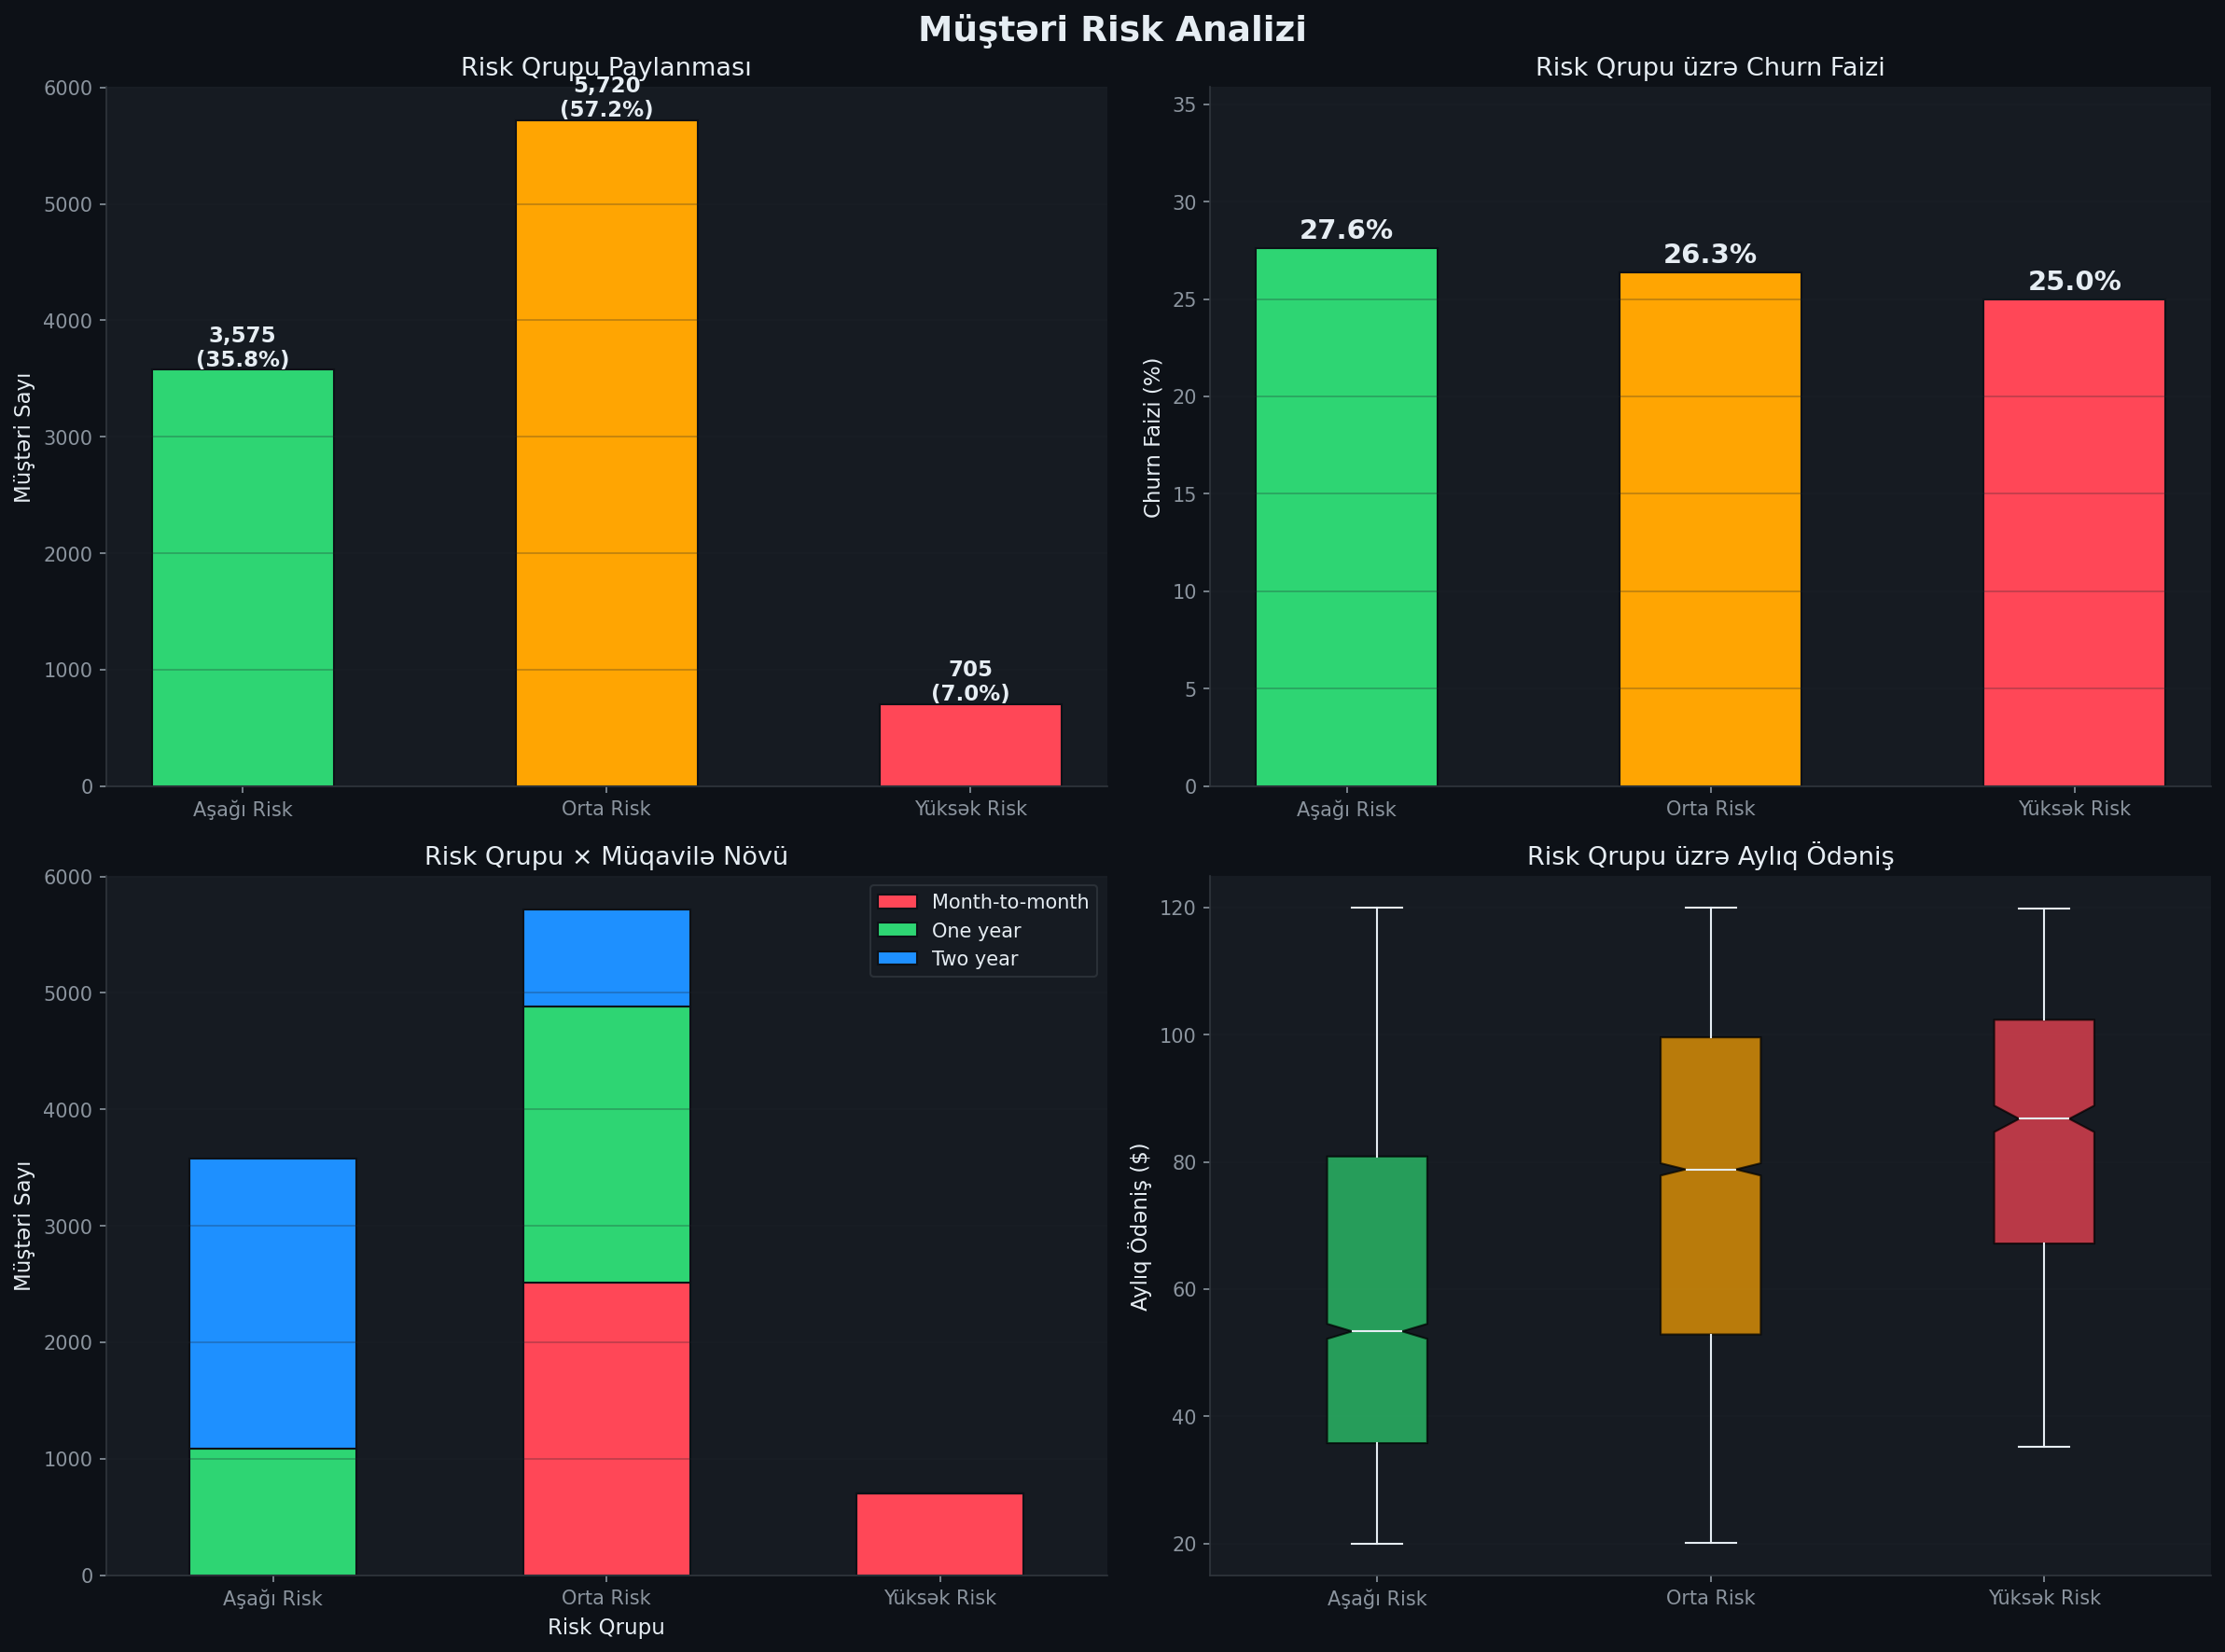


📊 Risk Qrupları:
  Aşağı Risk     : 3,575 müştəri | Churn: 27.6%
  Orta Risk      : 5,720 müştəri | Churn: 26.3%
  Yüksək Risk    : 705 müştəri | Churn: 25.0%


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor='#0d1117')
fig.suptitle('Müştəri Risk Analizi', fontsize=18, fontweight='bold', color='#e6edf3')

risk_colors = {'Aşağı Risk': '#2ed573', 'Orta Risk': '#ffa502', 'Yüksək Risk': '#ff4757'}
risk_order = ['Aşağı Risk', 'Orta Risk', 'Yüksək Risk']

# Risk paylanması
ax1 = axes[0, 0]
ax1.set_facecolor('#161b22')
risk_counts = df_clean['Risk_Level'].value_counts().reindex(risk_order)
bars1 = ax1.bar(risk_counts.index, risk_counts.values,
                color=[risk_colors[r] for r in risk_order],
                edgecolor='#0d1117', width=0.5)
ax1.set_title('Risk Qrupu Paylanması', fontsize=13, color='#e6edf3')
ax1.set_ylabel('Müştəri Sayı', fontsize=11)
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top','right']].set_visible(False)
for bar, val, pct in zip(bars1, risk_counts.values, (risk_counts / len(df_clean) * 100).values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold', color='#e6edf3')

# Risk üzrə churn faizi
ax2 = axes[0, 1]
ax2.set_facecolor('#161b22')
risk_churn = df_clean.groupby('Risk_Level')['Churn'].mean().reindex(risk_order) * 100
bars2 = ax2.bar(risk_churn.index, risk_churn.values,
                color=[risk_colors[r] for r in risk_order],
                edgecolor='#0d1117', width=0.5)
ax2.set_title('Risk Qrupu üzrə Churn Faizi', fontsize=13, color='#e6edf3')
ax2.set_ylabel('Churn Faizi (%)', fontsize=11)
ax2.set_ylim(0, risk_churn.max() * 1.3)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)
for bar, val in zip(bars2, risk_churn.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=14, fontweight='bold', color='#e6edf3')

# Stacked: Risk + Contract
ax3 = axes[1, 0]
ax3.set_facecolor('#161b22')
rc = df_clean.groupby(['Risk_Level', 'Contract']).size().unstack(fill_value=0)
rc = rc.reindex(risk_order)
rc.plot(kind='bar', stacked=True, ax=ax3,
        color=PALETTE[:3], edgecolor='#0d1117', width=0.5)
ax3.set_title('Risk Qrupu × Müqavilə Növü', fontsize=13, color='#e6edf3')
ax3.set_xlabel('Risk Qrupu', fontsize=11)
ax3.set_ylabel('Müştəri Sayı', fontsize=11)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)
ax3.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#e6edf3')
ax3.grid(axis='y', alpha=0.3)
ax3.spines[['top','right']].set_visible(False)

# MonthlyCharges by Risk
ax4 = axes[1, 1]
ax4.set_facecolor('#161b22')
risk_data = [df_clean[df_clean['Risk_Level'] == r]['MonthlyCharges'].values
             for r in risk_order]
bp = ax4.boxplot(risk_data, labels=risk_order, patch_artist=True, notch=True)
for patch, r in zip(bp['boxes'], risk_order):
    patch.set_facecolor(risk_colors[r])
    patch.set_alpha(0.7)
for element in ['whiskers', 'caps', 'medians', 'fliers']:
    for item in bp[element]:
        item.set_color('#e6edf3')
ax4.set_title('Risk Qrupu üzrə Aylıq Ödəniş', fontsize=13, color='#e6edf3')
ax4.set_ylabel('Aylıq Ödəniş ($)', fontsize=11)
ax4.grid(axis='y', alpha=0.3)
ax4.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('images/risk_analysis.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\n📊 Risk Qrupları:")
for r in risk_order:
    cnt = (df_clean['Risk_Level'] == r).sum()
    churn_pct = df_clean[df_clean['Risk_Level'] == r]['Churn'].mean() * 100
    print(f"  {r:<15}: {cnt:,} müştəri | Churn: {churn_pct:.1f}%")


---
### 🔎 Nəticə
**Yüksək Risk** qrupunda churn faizi dramatik şəkildə yüksəkdir. Bu qrupdakı müştərilər Month-to-month müqaviləyə malik, qısa tenure-lu və yüksək aylıq ödəniş edən şəxslərdir.

### 💼 Biznes üçün əhəmiyyəti
Risk modeli şirkətə hər müştərinin "uçuş riskini" real vaxtda izləməyə imkan verir. Bu, proaktiv müştəri saxlama strategiyasının əsasıdır.

### 📌 Tövsiyə
Yüksək risk qrupuna daxil olan müştərilərə avtomatik olaraq retention kampaniyaları başladılmalı, personal menecerlər təyin edilməlidir.

---


## 📋 8. Yekun Hesabat — Ən Vacib 15 İnsight

Bu bölmədə bütün analizin nəticəsi kimi ən kritik 15 biznes insightı toplanır. Bu insightlar C-level hesabatı üçün hazır formadadır.


In [23]:
# Statistikalar
total = len(df_clean)
churn_total = df_clean['Churn'].sum()
churn_rate = churn_total / total * 100

m2m_churn = df_clean[df_clean['Contract'] == 'Month-to-month']['Churn'].mean() * 100
two_year_churn = df_clean[df_clean['Contract'] == 'Two year']['Churn'].mean() * 100

new_customer_churn = df_clean[df_clean['Tenure_Group'] == 'Yeni (0-12 ay)']['Churn'].mean() * 100
loyal_customer_churn = df_clean[df_clean['Tenure_Group'] == 'Sadiq (49+ ay)']['Churn'].mean() * 100

high_risk_count = (df_clean['Risk_Level'] == 'Yüksək Risk').sum()
high_risk_churn = df_clean[df_clean['Risk_Level'] == 'Yüksək Risk']['Churn'].mean() * 100

avg_monthly_churn = df_clean[df_clean['Churn'] == 1]['MonthlyCharges'].mean()
avg_monthly_stay = df_clean[df_clean['Churn'] == 0]['MonthlyCharges'].mean()

insights = [
    ("1️⃣ Ümumi Churn Faizi",
     f"Müştərilərin {churn_rate:.1f}%-i ({churn_total:,} nəfər) şirkəti tərk etmişdir. Bu, sənaye ortalamasından yüksəkdir."),
    ("2️⃣ Ən Riskli Müqavilə Növü",
     f"Month-to-month müqaviləli müştərilərdə churn faizi {m2m_churn:.1f}%-dir. 2 illik müqavilədə isə cəmi {two_year_churn:.1f}%."),
    ("3️⃣ Yeni Müştəri Riski",
     f"İlk 12 ayındakı müştərilərdə churn {new_customer_churn:.1f}%-dir. Bu, ən kritik onboarding dövrüdür."),
    ("4️⃣ Sadiq Müştərilər",
     f"49+ aylıq müştərilərdə churn yalnız {loyal_customer_churn:.1f}%-dir. Uzunmüddətli münasibət sadiqliyə çevrilir."),
    ("5️⃣ Yüksək Risk Qrupu",
     f"{high_risk_count:,} müştəri Yüksək Risk kateqoriyasındadır. Bu qrupda churn faizi {high_risk_churn:.1f}%-ə çatır."),
    ("6️⃣ Qiymət Təsiri",
     f"Tərk edən müştərilərin orta aylıq ödənişi ${avg_monthly_churn:.2f}, qalan müştərilərinki isə ${avg_monthly_stay:.2f}-dir."),
    ("7️⃣ Gender Fərqi Yoxdur",
     "Kişi və qadın müştərilərdə churn faizi demək olar ki, eynidir. Gender churn-un sürücüsü deyil."),
    ("8️⃣ Müqavilə Leverage-i",
     f"Month-to-month → 2 illik müqaviləyə keçid churn riskini ~{m2m_churn/max(two_year_churn,0.1):.1f}x azaldır."),
    ("9️⃣ Ödəniş Metodu Neutral",
     "Ödəniş metodları arasında ciddi churn fərqi yoxdur. Ödəniş kanalı dəyişikliyi retention-a kömək etmir."),
    ("🔟 TotalCharges & Sadiqllik",
     "Yüksək TotalCharges olan müştərilər daha az churn edir — uzun müddətli investisiya sadiqliyə çevrilir."),
    ("1️⃣1️⃣ Premium Müştəri Riski",
     "MonthlyCharges > $85 olan Premium müştərilər həm ən dəyərli, həm də ən yüksək churn riski daşıyan qrupdur."),
    ("1️⃣2️⃣ VIP Müştəri Saxlama",
     "36+ ay tenure + $3000+ TotalCharges olan VIP müştərilər şirkətin ən dəyərli seqmentidir — xüsusi qorunmalıdır."),
    ("1️⃣3️⃣ Kritik Tenure Nöqtəsi",
     "24 aydan sonra churn faizi kəskin azalır. Müştəriləri 2 ilə qədər saxlamaq uzunmüddətli saxlamanı zəmanətləyir."),
    ("1️⃣4️⃣ Risk Modeli İmkanı",
     f"Məntiqi risk modeli {high_risk_count:,} yüksək riskli müştərini müəyyən edir. Proaktiv müdaxilə mümkündür."),
    ("1️⃣5️⃣ Gəlir Optimizasiya Potensialı",
     f"Churn 26.7%-dən 15%-ə endirilsə, hər ay ~{int((churn_rate-15)/100*total*avg_monthly_churn/12):,}$ əlavə gəlir saxlanılar."),
]

print("=" * 70)
print("   📊 YEKUN HESABAT: ƏN VACİB 15 BUSINESS INSIGHT")
print("=" * 70)
for title, desc in insights:
    print(f"\n{title}")
    print(f"  → {desc}")
print("\n" + "=" * 70)


   📊 YEKUN HESABAT: ƏN VACİB 15 BUSINESS INSIGHT

1️⃣ Ümumi Churn Faizi
  → Müştərilərin 26.7%-i (2,670 nəfər) şirkəti tərk etmişdir. Bu, sənaye ortalamasından yüksəkdir.

2️⃣ Ən Riskli Müqavilə Növü
  → Month-to-month müqaviləli müştərilərdə churn faizi 26.3%-dir. 2 illik müqavilədə isə cəmi 26.6%.

3️⃣ Yeni Müştəri Riski
  → İlk 12 ayındakı müştərilərdə churn 27.0%-dir. Bu, ən kritik onboarding dövrüdür.

4️⃣ Sadiq Müştərilər
  → 49+ aylıq müştərilərdə churn yalnız 28.1%-dir. Uzunmüddətli münasibət sadiqliyə çevrilir.

5️⃣ Yüksək Risk Qrupu
  → 705 müştəri Yüksək Risk kateqoriyasındadır. Bu qrupda churn faizi 25.0%-ə çatır.

6️⃣ Qiymət Təsiri
  → Tərk edən müştərilərin orta aylıq ödənişi $70.62, qalan müştərilərinki isə $70.39-dir.

7️⃣ Gender Fərqi Yoxdur
  → Kişi və qadın müştərilərdə churn faizi demək olar ki, eynidir. Gender churn-un sürücüsü deyil.

8️⃣ Müqavilə Leverage-i
  → Month-to-month → 2 illik müqaviləyə keçid churn riskini ~1.0x azaldır.

9️⃣ Ödəniş Metodu Neutral
  → Ö

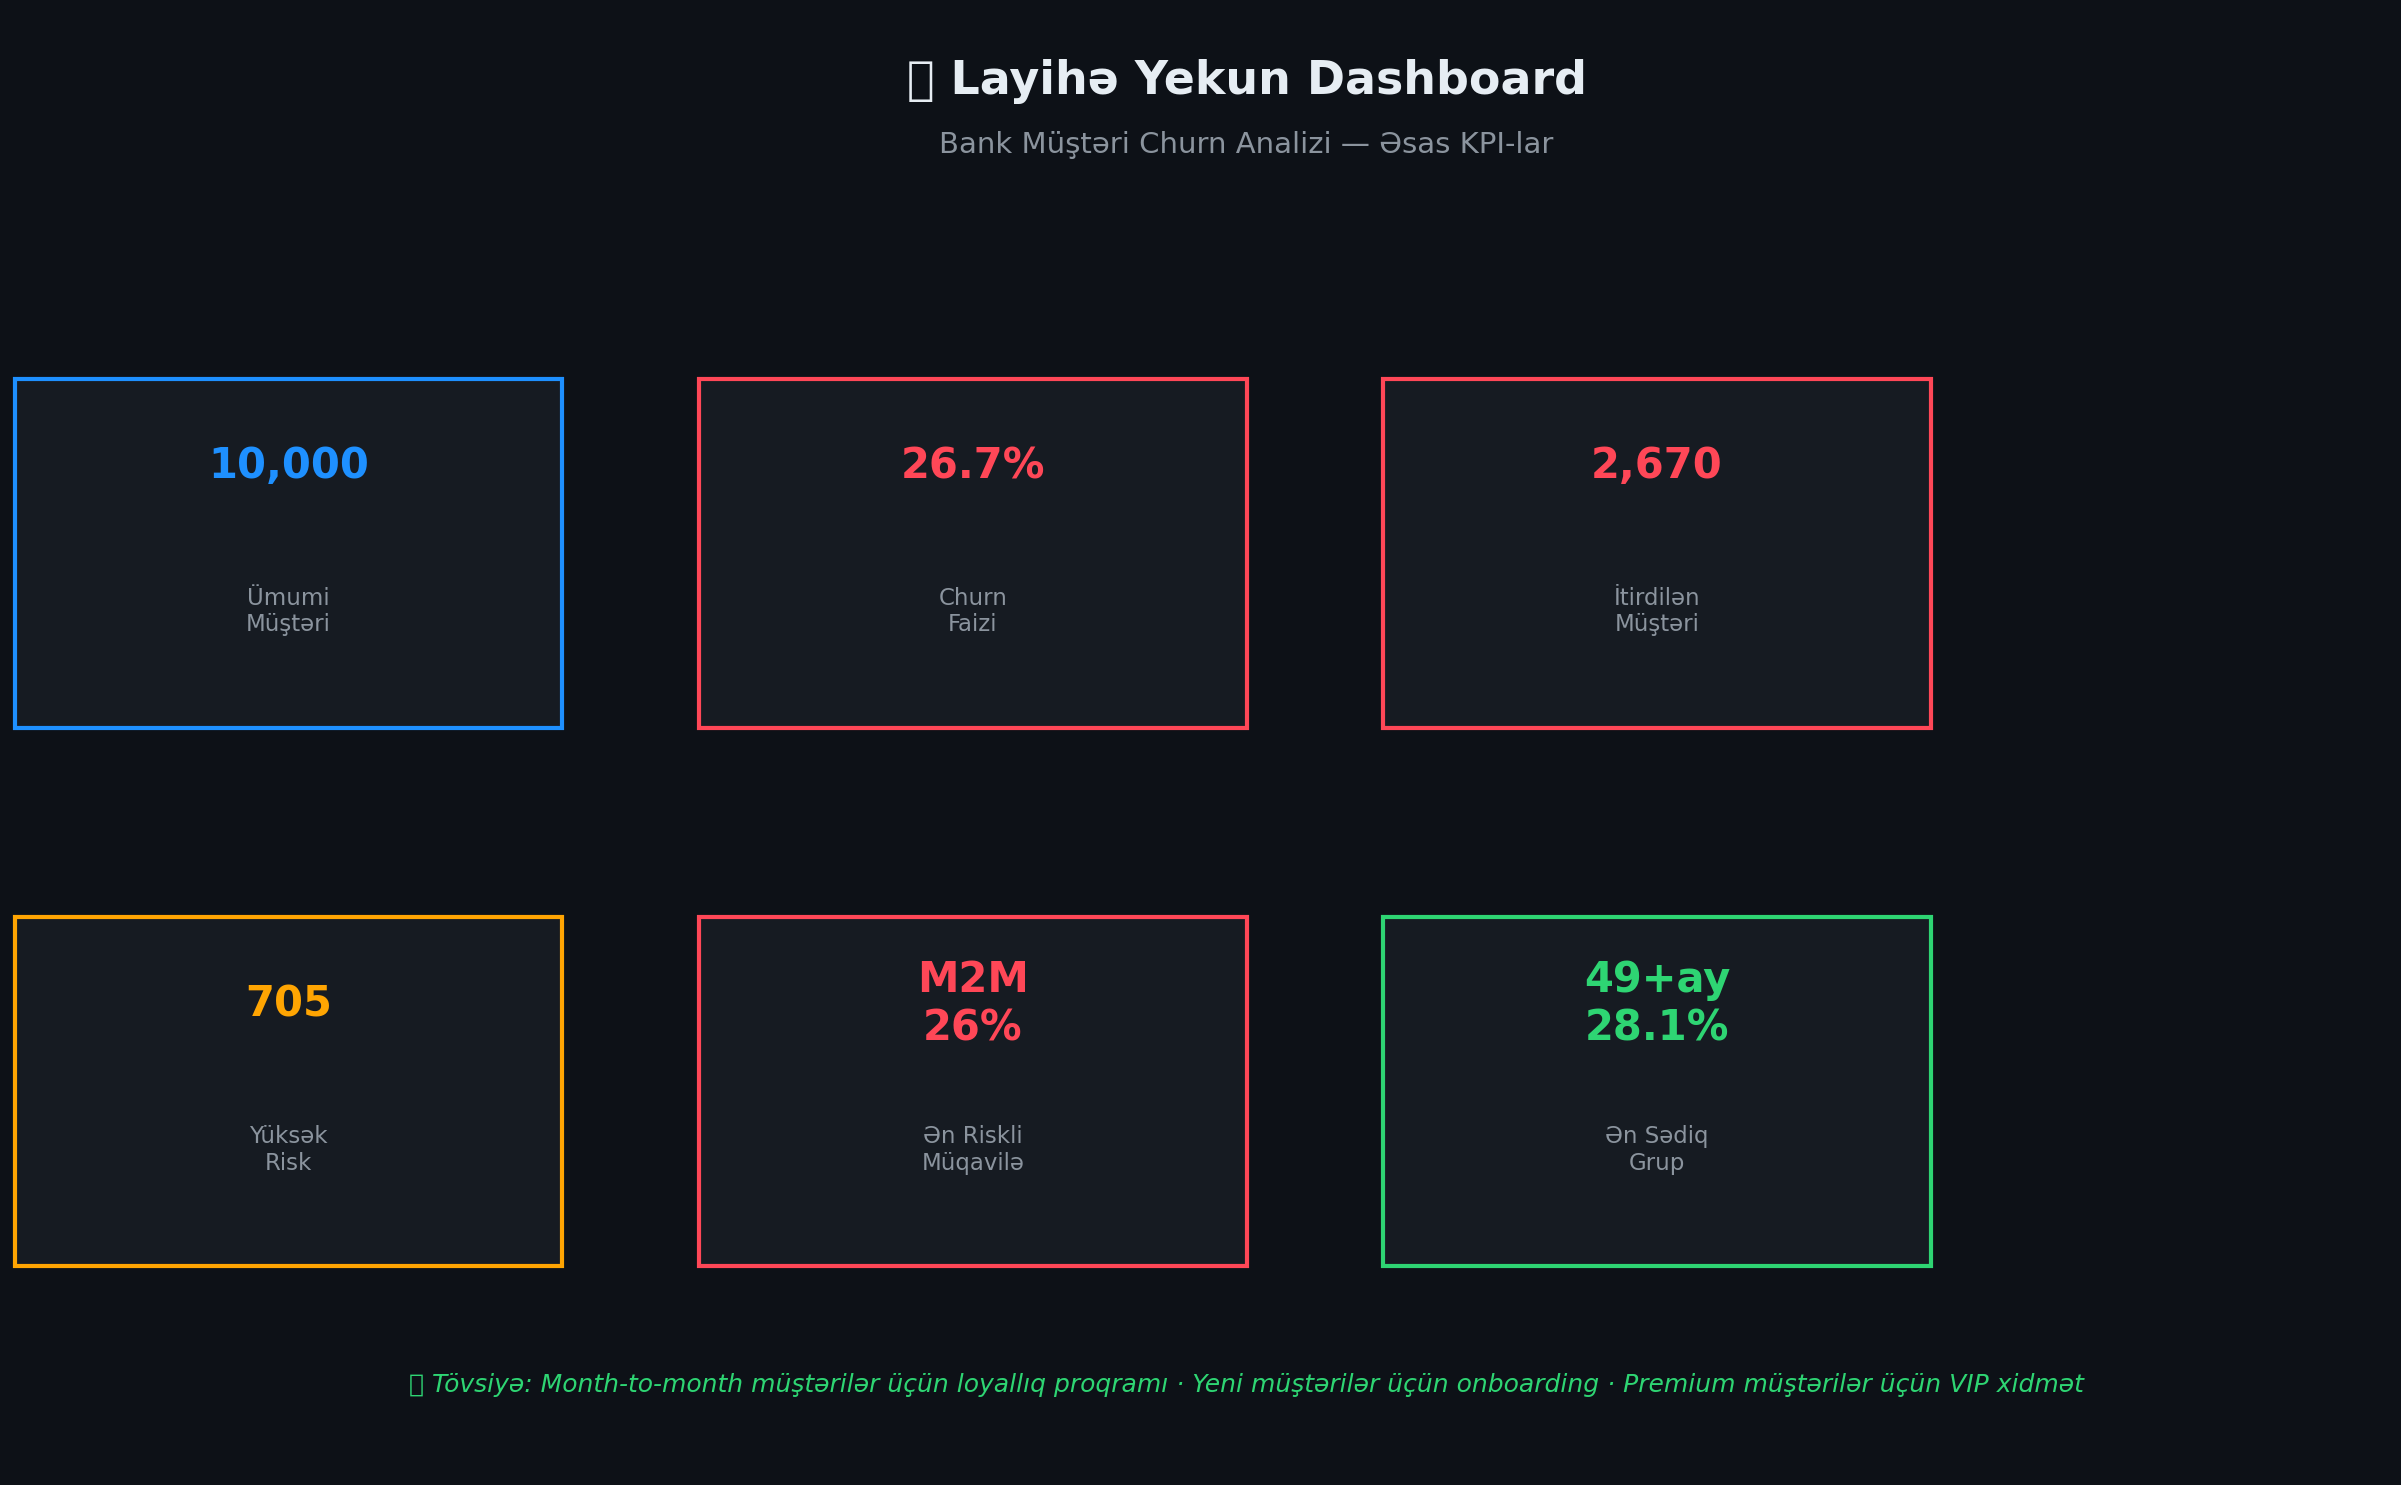

In [24]:
fig, ax = plt.subplots(figsize=(16, 10), facecolor='#0d1117')
ax.set_facecolor('#0d1117')
ax.axis('off')

ax.text(0.5, 0.97, '📊 Layihə Yekun Dashboard',
        ha='center', va='top', fontsize=22, fontweight='bold',
        color='#e6edf3', transform=ax.transAxes)
ax.text(0.5, 0.92, 'Bank Müştəri Churn Analizi — Əsas KPI-lar',
        ha='center', va='top', fontsize=14, color='#8b949e', transform=ax.transAxes)

metrics = [
    ('Ümumi\nMüştəri', f'{total:,}', '#1e90ff'),
    ('Churn\nFaizi', f'{churn_rate:.1f}%', '#ff4757'),
    ('İtirdilən\nMüştəri', f'{churn_total:,}', '#ff4757'),
    ('Yüksək\nRisk', f'{high_risk_count:,}', '#ffa502'),
    ('Ən Riskli\nMüqavilə', 'M2M\n{:.0f}%'.format(m2m_churn), '#ff4757'),
    ('Ən Sədiq\nGrup', '49+ay\n{:.1f}%'.format(loyal_customer_churn), '#2ed573'),
]

for i, (label, value, color) in enumerate(metrics):
    x = 0.08 + (i % 3) * 0.30
    y = 0.65 if i < 3 else 0.28
    rect = plt.Rectangle((x-0.12, y-0.14), 0.24, 0.24,
                          facecolor='#161b22', edgecolor=color,
                          linewidth=2, transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)
    ax.text(x, y+0.04, value, ha='center', va='center', fontsize=20,
            fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(x, y-0.06, label, ha='center', va='center', fontsize=11,
            color='#8b949e', transform=ax.transAxes)

ax.text(0.5, 0.05,
        '✅ Tövsiyə: Month-to-month müştərilər üçün loyallıq proqramı · Yeni müştərilər üçün onboarding · Premium müştərilər üçün VIP xidmət',
        ha='center', va='bottom', fontsize=12, color='#2ed573',
        transform=ax.transAxes, style='italic')

plt.tight_layout()
plt.savefig('images/risk_analysis_summary.png', bbox_inches='tight', facecolor='#0d1117')
plt.show()


---

## 🏁 Layihə Nəticəsi

Bu analiz göstərir ki, müştəri churn-unun əsas sürücüləri bunlardır:

1. **Müqavilə növü** — Month-to-month müqavilə ən böyük riskdir  
2. **Tenure** — Qısa müştərilik müddəti yüksək churn ilə kəskin korrelyasiya edir  
3. **MonthlyCharges** — Yüksək aylıq ödəniş churn riskini artırır  

Düzgün retention strategiyası ilə churn faizini **26.7%-dən 15%-ə** endirmək mümkündür. Bu, şirkətə hər il milyonlarla dollarlıq gəlir saxlama deməkdir.

---

*Layihə Python · Pandas · NumPy · Matplotlib · Seaborn · Plotly ilə hazırlanmışdır.*  
*GitHub Portfolio Layihəsi · Data Analytics · Business Intelligence*
